<div style="display: flex; align-items: center; justify-content: space-between">
    <div>
        <img src="https://raw.githubusercontent.com/sebastianVP/RADAR_AMISR/refs/heads/main/igp_logo.jpeg"
         alt="LOGO IGP" width="200" height="200" style="margin-left: 20px; border-radius: 10px;" align = "right">
        <h1 style="color: #800020;  font-weight: bold; margin-bottom: 10px; font-family: Arial, sans-serif;">
          <font color="#7F000E">
            Maestría de Ciencias de la Computación UNI-IGP
          </font>
        </h1>
        <h2 style="color: #800020;font-weight: bold; max-width: 750px; font-family: Arial, sans-serif;">
          <strong><font color="#7F000E" size=5 >
            Desarrollo de sistema de pronóstico de centelleo ionosférico sobre el Perú para alerta de
            perturbaciones en señales satelitales
          </font ></strong>
        </h2>
    </div>
</div>
<div>
    <p style="margin-bottom: 5px;">
    <strong>
    <font color="#7F000E" size=4 >Avance de Tesis - PASO 3 -CIENCIA DE DATOS </strong></p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Alumno:</strong></font>
    <font color="#7F000E"> Alexander Valdez Portocarrero</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Código:</strong> 20207072E</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong>Fecha:</strong>  12/02/2026 - UPDATE FINAL</p>
    <p style="margin-bottom: 5px;">
    <font color="#7F000E"><strong> Ciclo 2025-2</strong></p>
</div>

---

# **I) ETAPA 1**

# **0. LIBRERIAS**

In [28]:
# =============================================================================
# MODULO DE PREPROCESAMIENTO PARA CINTILACIONES IONOSFÉRICAS
# Autor: Alexander Valdez Portocarrero
# Descripción: Carga, análisis exploratorio y preparación de tensores para LSTM
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os,gc
import tensorflow as tf # Solo si necesitas verificar GPU aquí
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Importaciones específicas de Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Intentar importar seaborn para un mejor heatmap, si no, usamos matplotlib plano
try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ImportError:
    SEABORN_AVAILABLE = False

In [30]:
# VERIFICAR TensorFlow
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

print("\nGPUs detectadas:")
print(tf.config.list_physical_devices('GPU'))

print("\n¿CUDA disponible?")
print(len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow Version: 2.19.0

GPUs detectadas:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

¿CUDA disponible?
True


# **1. CARGA DE DATOS**

In [29]:
def cargar_dataset(path, filename):
    """
    Carga el CSV y realiza la conversión inicial de fechas.
    """
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"No se encontró el archivo en: {full_path}")

    print(f"📂 Cargando archivo: {filename}...")
    df = pd.read_csv(full_path)

    # Conversión única y definitiva a datetime
    df["Tiempo"] = pd.to_datetime(df["Tiempo"])

    # Ordenar cronológicamente (vital para series temporales)
    df = df.sort_values("Tiempo")

    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango de fechas: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

# **2. ANALISIS EXPLORATORIO(EDA)**

In [4]:
def analizar_eventos_cintilacion(df, umbral_s4=0.6, plot=True):
    """
    Analiza y visualiza los días con presencia de cintilación.
    No modifica el DF original permanentemente, solo reporta estadísticas.
    """
    print("\n🔍 Analizando distribución de eventos...")

    # Trabajamos con una copia ligera para no alterar el original
    df_analisis = df[["Tiempo", "S4"]].copy()
    df_analisis["Fecha"] = df_analisis["Tiempo"].dt.date

    # 1. Identificar si cada día superó el umbral
    resumen_diario = df_analisis.groupby("Fecha")["S4"].max() > umbral_s4
    resumen_diario = resumen_diario.reset_index()
    resumen_diario.columns = ["Fecha", "Evento_Cintilacion"] # True/False

    total_dias = resumen_diario["Fecha"].nunique()
    dias_con_evento = resumen_diario["Evento_Cintilacion"].sum()

    print(f"   Total de días registrados: {total_dias}")
    print(f"   Días con eventos (S4 > {umbral_s4}): {dias_con_evento}")
    print(f"   Porcentaje de actividad: {(dias_con_evento/total_dias)*100:.2f}%")

    # 2. Reporte Mensual
    df_analisis["Mes"] = df_analisis["Tiempo"].dt.to_period("M")

    # Unimos para saber qué día tuvo evento
    # Primero agrupamos por día para saber si ESE día hubo evento
    max_s4_dia = df_analisis.groupby(["Mes", "Fecha"])["S4"].max().reset_index()
    max_s4_dia["Tuvo_Evento"] = (max_s4_dia["S4"] > umbral_s4).astype(int)

    # Tabla resumen
    tabla_mensual = max_s4_dia.groupby("Mes")["Tuvo_Evento"].agg(
        Dias_Con_Cintilacion='sum',
        Total_Dias='count'
    )
    tabla_mensual["Dias_Sin_Cintilacion"] = tabla_mensual["Total_Dias"] - tabla_mensual["Dias_Con_Cintilacion"]

    print("\n📊 Resumen Mensual de Actividad:")
    print(tabla_mensual)

    # 3. Visualización (Opcional)
    if plot:
        plt.figure(figsize=(12, 5))
        # Convertimos a string para que matplotlib no haga lío con fechas
        fechas_str = resumen_diario["Fecha"].astype(str)
        valores = resumen_diario["Evento_Cintilacion"].astype(int)

        plt.bar(fechas_str, valores, color=np.where(valores==1, 'orange', 'skyblue'))
        plt.title(f"Días con Cintilación (S4 > {umbral_s4})")
        plt.ylabel("Presencia (1=Sí, 0=No)")
        plt.xticks(rotation=90, fontsize=8)

        # Mostrar solo una etiqueta cada 7 días para no saturar
        ax = plt.gca()
        for index, label in enumerate(ax.xaxis.get_ticklabels()):
            if index % 7 != 0:
                label.set_visible(False)

        plt.tight_layout()
        plt.show()

# **3. FEATURE ENGINEERING**

In [5]:
# =============================================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# =============================================================================
def agregar_caracteristicas_temporales(df):
    """
    Agrega transformaciones cíclicas de tiempo (Seno/Coseno).
    """
    print("\n⚙️ Generando características temporales (Sin/Cos)...")

    # Calcular minuto del día (0–1439)
    minutos_dia = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute
    periodo = 24 * 60 # 1440 minutos

    # Transformación
    df["Hora_Sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["Hora_Cos"] = np.cos(2 * np.pi * minutos_dia / periodo)

    return df

# **RESULTADOS Y EVALUACION**

# **NOTA :**

**CASO 1:**
============================================================
- /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
- Trabajamos con el archivo: df_FINAL_JICAMARCA.csv
     * 📂 Cargando archivo: df_FINAL_JICAMARCA.csv...
     * ✅ Dataset cargado. Shape: (449844, 15)
     *  Rango de fechas: 2025-01-26 00:35:00 a 2025-12-31 23:45:00

🔍 Analizando distribución de eventos...
  *  Total de días registrados: 328
  *  Días con eventos (S4 > 0.6): 65
  *  Porcentaje de actividad: 19.82%
     


RUTA : /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
Trabajamos con el archivo: df_FINAL_JICAMARCA.csv
📂 Cargando archivo: df_FINAL_JICAMARCA.csv...
✅ Dataset cargado. Shape: (449844, 15)
   Rango de fechas: 2025-01-26 00:35:00 a 2025-12-31 23:45:00

🔍 Analizando distribución de eventos...
   Total de días registrados: 328
   Días con eventos (S4 > 0.6): 65
   Porcentaje de actividad: 19.82%

📊 Resumen Mensual de Actividad:
         Dias_Con_Cintilacion  Total_Dias  Dias_Sin_Cintilacion
Mes                                                            
2025-01                     3           6                     3
2025-02                    15          26                    11
2025-03                    10          31                    21
2025-04                     2          29                    27
2025-05                     0          31                    31
2025-06                     0          27                    27
2025-07                     0          29 

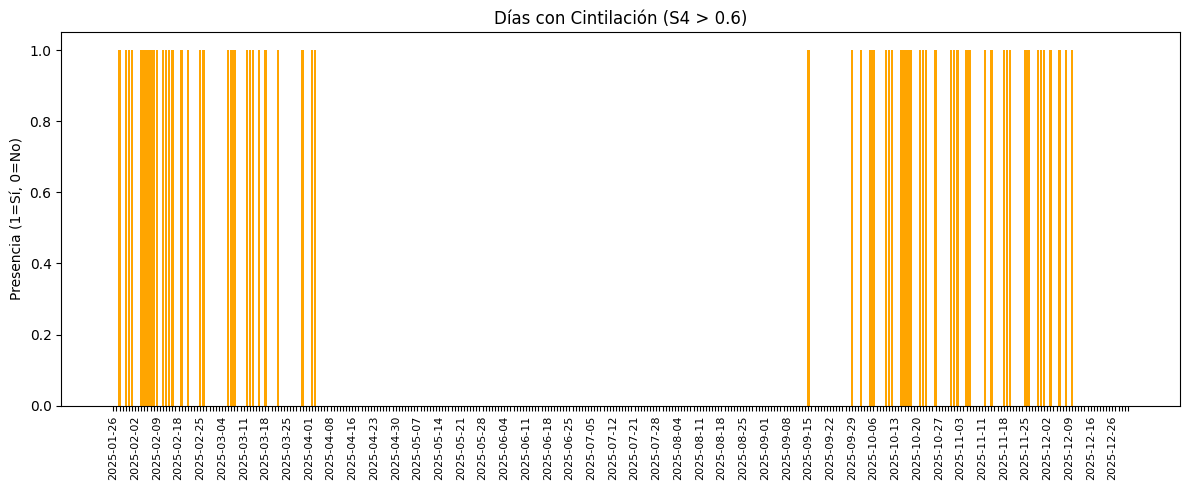


⚙️ Generando características temporales (Sin/Cos)...


In [6]:
if __name__ == "__main__":

    # 1. Configuración
    N_ESTACION  = 0  # Escoge la estacion
    ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]

    RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    #RUTA_DRIVE = "/content/drive/MyDrive/MAESTRIA_ARTICULO_2026/data"
    #RUTA_DRIVE  = "/content/drive/MyDrive/MAESTRIA_MCC_2024_2/PROCIENCIA_TESIS/DATA_2023_2025_PROC"
    #ARCHIVO         = "df_FINAL.csv"
    ARCHIVO     = f"df_FINAL_{ESTACION[N_ESTACION]}.csv"
    print("="*60)
    #print(f"RUTA DRIVE: {RUTA_DRIVE}")
    print(f"RUTA : {RUTA}")
    print(f"Trabajamos con el archivo: {ARCHIVO}")
    print("="*60)

    # Definición de Features para el modelo (Orden Importante)
    FEATURES_COLS = [
        'S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index',
        'Hora_Sin', 'Hora_Cos'
    ]

    # 2. Pipeline de ejecución
    # Cargar
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    #df_raw = cargar_dataset(RUTA_DRIVE, ARCHIVO)
    #df_raw = cargar_dataset(RUTA_DRIVE_HYO, ARCHIVO_HYO)

    # Analizar (No modifica df_raw)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=True)

    # Ingeniería de Features (Modifica df_raw)
    df_features = agregar_caracteristicas_temporales(df_raw)

In [7]:
df_features

,Tiempo,ID_Satelite,Azimuth,Elevacion,is_Outlier,Cintilacion,TEC,ROTEC,ROTI,S4,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,Hora_Sin,Hora_Cos
0,2025-01-26 00:35:00,39.0,189.0,31.0,False,0.0,70.689140,-0.012351,0.010958,0.161,3.000000,-1.416667,2.00,165.40,29.083333,0.152123,0.988362
1,2025-01-26 00:36:00,205.0,61.0,62.0,False,0.0,70.778647,-0.010967,0.010961,0.166,3.000000,-1.400000,2.00,165.40,29.000000,0.156434,0.987688
2,2025-01-26 00:37:00,13.0,197.0,32.0,False,0.0,70.868153,-0.009583,0.010964,0.128,3.000000,-1.383333,2.00,165.40,28.916667,0.160743,0.986996
3,2025-01-26 00:38:00,205.0,61.0,62.0,False,0.0,70.957660,-0.008198,0.010966,0.134,3.000000,-1.366667,2.00,165.40,28.833333,0.165048,0.986286
4,2025-01-26 00:39:00,205.0,61.0,62.0,False,0.0,71.047166,-0.006814,0.010969,0.136,3.000000,-1.350000,2.00,165.40,28.750000,0.169350,0.985556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449839,2025-12-31 23:41:00,42.0,118.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.119,16.833333,13.000000,6.05,163.98,3227.850000,-0.082808,0.996566
449840,2025-12-31 23:42:00,42.0,118.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.111,17.000000,13.000000,6.10,163.96,3062.700000,-0.078459,0.996917
449841,2025-12-31 23:43:00,42.0,117.0,32.0,False,0.0,28.705915,0.003217,0.000796,0.092,17.166667,13.000000,6.15,163.94,2897.550000,-0.074108,0.997250
449842,2025-12-31 23:44:00,30.0,177.0,49.0,False,0.0,28.705915,0.003217,0.000796,0.106,17.333333,13.000000,6.20,163.92,2732.400000,-0.069756,0.997564


**CASO 2:**
============================================================
-/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
-Trabajamos con el archivo: /home/soporte/Documents/pipelines_cip/INTEGRACION/integrated_dataset/dataset_integrado_jic.csv

    *  📂 Cargando archivo: dataset_integrado_jic.csv...
    *  ✅ Dataset cargado. Shape: (616512, 14)
    *  Rango de fechas: 2025-01-26 00:35:00 a 2026-05-22 14:35:00

🔍 Analizando distribución de eventos...
   * Total de días registrados: 454
   * Días con eventos (S4 > 0.6): 97
   * Porcentaje de actividad: 21.37%

RUTA : /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
Trabajamos con el archivo: /home/soporte/Documents/pipelines_cip/INTEGRACION/integrated_dataset/dataset_integrado_jic.csv
📂 Cargando archivo: /home/soporte/Documents/pipelines_cip/INTEGRACION/integrated_dataset/dataset_integrado_jic.csv...
✅ Dataset cargado. Shape: (616512, 14)
   Rango de fechas: 2025-01-26 00:35:00 a 2026-05-22 14:35:00

🔍 Analizando distribución de eventos...
   Total de días registrados: 454
   Días con eventos (S4 > 0.6): 97
   Porcentaje de actividad: 21.37%

📊 Resumen Mensual de Actividad:
         Dias_Con_Cintilacion  Total_Dias  Dias_Sin_Cintilacion
Mes                                                            
2025-01                     3           6                     3
2025-02                    15          26                    11
2025-03                    10          31                    21
2025-04                     2          29                    27
2025-05                   

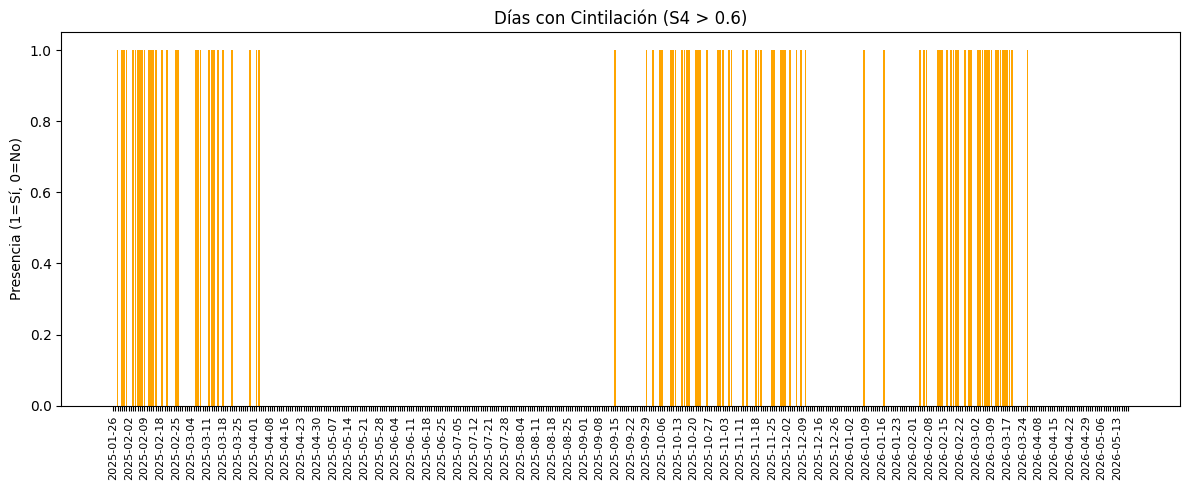


⚙️ Generando características temporales (Sin/Cos)...


In [8]:
if __name__ == "__main__":

    # 1. Configuración
    N_ESTACION  = 0  # Escoge la estacion
    ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]

    RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
    ARCHIVO     = f"df_FINAL_{ESTACION[N_ESTACION]}.csv"
    ARCHIVO     = "/home/soporte/Documents/pipelines_cip/INTEGRACION/integrated_dataset/dataset_integrado_jic.csv"
    print("="*60)
    print(f"RUTA : {RUTA}")
    print(f"Trabajamos con el archivo: {ARCHIVO}")
    print("="*60)

    # Definición de Features para el modelo (Orden Importante)
    FEATURES_COLS = [
        'S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index',
        'Hora_Sin', 'Hora_Cos'
    ]

    # 2. Pipeline de ejecución
    # Cargar
    df_raw = cargar_dataset(RUTA, ARCHIVO)

    # Analizar (No modifica df_raw)
    analizar_eventos_cintilacion(df_raw, umbral_s4=0.6, plot=True)

    # Ingeniería de Features (Modifica df_raw)
    df_features_new = agregar_caracteristicas_temporales(df_raw)

In [9]:
df_features_new

,Tiempo,ID_Satelite,Azimuth,Elevacion,Estacion,TEC,ROTEC,ROTI,Kp_Index,Dst_Index,ap_Index,f10.7_Index,AE_Index,S4,Hora_Sin,Hora_Cos
0,2025-01-26 00:35:00,39.0,189.0,31.0,JICAMARCA,70.689140,-0.012351,0.010958,3.000000,-1.416667,2.000000,165.4,29.083333,0.161,0.152123,0.988362
1,2025-01-26 00:36:00,39.0,189.0,32.0,JICAMARCA,70.778647,-0.010967,0.010961,3.000000,-1.400000,2.000000,165.4,29.000000,0.122,0.156434,0.987688
2,2025-01-26 00:37:00,13.0,197.0,32.0,JICAMARCA,70.868153,-0.009583,0.010964,3.000000,-1.383333,2.000000,165.4,28.916667,0.128,0.160743,0.986996
3,2025-01-26 00:38:00,39.0,189.0,33.0,JICAMARCA,70.957660,-0.008198,0.010966,3.000000,-1.366667,2.000000,165.4,28.833333,0.106,0.165048,0.986286
4,2025-01-26 00:39:00,13.0,196.0,32.0,JICAMARCA,71.047166,-0.006814,0.010969,3.000000,-1.350000,2.000000,165.4,28.750000,0.103,0.169350,0.985556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616507,2026-05-22 14:31:00,30.0,172.0,42.0,JICAMARCA,13.520898,-0.000981,0.000489,5.066667,-2.450000,2.516667,127.5,47.000000,0.126,-0.612217,-0.790690
616508,2026-05-22 14:32:00,41.0,170.0,34.0,JICAMARCA,13.470268,-0.000947,0.000421,5.133333,-2.400000,2.533333,127.5,47.000000,0.171,-0.615661,-0.788011
616509,2026-05-22 14:33:00,41.0,169.0,34.0,JICAMARCA,13.419638,-0.000912,0.000354,5.200000,-2.350000,2.550000,127.5,47.000000,0.134,-0.619094,-0.785317
616510,2026-05-22 14:34:00,41.0,169.0,34.0,JICAMARCA,13.369008,-0.000878,0.000286,5.266667,-2.300000,2.566667,127.5,47.000000,0.199,-0.622515,-0.782608


# **ETAPA II**

# **4. PREPARACIÓN FINAL DE ESTRUCTURA**

In [10]:
def finalizar_estructura_df(df, target_col="S4"):
    """
    Limpia columnas auxiliares, reordena y establece el índice temporal.
    Esta función deja el DF listo para entrar al Generador de Ventanas.
    """
    print("\n🧹 Finalizando estructura del DataFrame...")

    # 1. Asegurar índice temporal
    if df.index.name != 'Tiempo':
        df = df.set_index('Tiempo')

    df = df.sort_index()

    # 2. Reordenar columnas: Target al final (práctica estándar)
    cols = [c for c in df.columns if c != target_col]
    cols.append(target_col)
    df = df[cols]

    # 3. Eliminar columnas que ya no sirven para el modelo numérico
    # (Ej: Fechas string, columnas categóricas, etc.)
    cols_a_borrar = ["dias", "Fecha", "Mes", "minuto_del_dia", "Cintilacion"]
    # Borramos solo si existen
    cols_existentes = [c for c in cols_a_borrar if c in df.columns]

    if cols_existentes:
        df = df.drop(columns=cols_existentes)
        print(f"   Columnas eliminadas: {cols_existentes}")

    print(f"✅ DataFrame Final Listo. Shape: {df.shape}")
    print(f"   Columnas finales: {df.columns.tolist()}")

    return df

# **5. ESTRATEGIA DE DIVISIÓN DE DATOS -DATASPLITTING**

In [11]:
# =============================================================================
# 5. ESTRATEGIA DE DIVISIÓN DE DATOS (DATA SPLITTING)
# =============================================================================
def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    """
    Divide el dataset asegurando que haya días con tormentas en Train, Val y Test.
    Mantiene la integridad interna de cada día completo.
    """
    print("\n✂️ Ejecutando división estratificada de datos...")

    # Recuperamos la fecha del índice de forma segura
    fechas_unicas = np.unique(df.index.date)
    
    # Crear un DataFrame temporal de mapeo diario para calcular máximos de S4
    temp_diario = pd.DataFrame(index=df.index)
    temp_diario['Fecha'] = df.index.date
    temp_diario['S4'] = df['S4'].values
    
    resumen_diario = temp_diario.groupby('Fecha')['S4'].max().reset_index()

    # Identificar Días Activos vs Días Quietos
    dias_activos = resumen_diario[resumen_diario['S4'] > umbral_s4]['Fecha'].values
    dias_quietos = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values
    
    print("-------- Distribución Original de Días ------------")
    print(f"   Total Días Activos encontrados: {len(dias_activos)}")
    print(f"   Total Días Quietos encontrados: {len(dias_quietos)}")

    # Opcional: Si deseas aplicar el submuestreo de días quietos que tenías comentado:
    # dias_quietos = dias_quietos[:len(dias_activos)]

    # 2. Repartir los Días ACTIVOS (70% Train, 15% Val, 15% Test)
    activos_train, activos_temp = train_test_split(dias_activos, test_size=0.3, random_state=42)
    activos_val, activos_test = train_test_split(activos_temp, test_size=0.5, random_state=42)

    # 3. Repartir los Días QUIETOS
    quietos_train, quietos_temp = train_test_split(dias_quietos, test_size=0.3, random_state=42)
    quietos_val, quietos_test = train_test_split(quietos_temp, test_size=0.5, random_state=42)

    # 4. Combinar las listas por conjunto
    lista_dias_train = np.concatenate([activos_train, quietos_train])
    lista_dias_val = np.concatenate([activos_val, quietos_val])
    lista_dias_test = np.concatenate([activos_test, quietos_test])

    # 5. Crear los DataFrames Finales filtrando por el objeto fecha del índice
    train = df[df.index.date.astype(object) == pd.Series(df.index.date).isin(lista_dias_train).values] # Filtrado eficiente
    
    # Método alternativo ultra-seguro usando máscaras booleanas basadas en el índice
    df_dates = pd.Series(df.index.date)
    train = df[df_dates.isin(lista_dias_train).values].sort_index()
    val = df[df_dates.isin(lista_dias_val).values].sort_index()
    test = df[df_dates.isin(lista_dias_test).values].sort_index()

    return train, val, test

def auditar_division_datos(df, nombre_set, umbral_s4=0.6):
    """
    Función auxiliar para verificar que cada set tenga eventos.
    """
    if df.empty:
        print(f"⚠️ PELIGRO: El set {nombre_set} está completamente vacío.")
        return

    fechas = df.index.date
    s4_values = df['S4'].values
    df_temp = pd.DataFrame({'Fecha': fechas, 'S4': s4_values})

    dias_totales = df_temp['Fecha'].nunique()
    dias_con_evento = df_temp[df_temp['S4'] > umbral_s4]['Fecha'].nunique()

    porcentaje = (dias_con_evento / dias_totales) * 100 if dias_totales > 0 else 0

    print(f"--- AUDITORÍA: {nombre_set.upper()} ---")
    print(f"📅 Días totales: {dias_totales} | ⚡ Con Cintilación: {dias_con_evento}")
    print(f"📊 Porcentaje actividad: {porcentaje:.2f}%")
    print("✅ Set válido." if dias_con_evento > 0 else f"⚠️ PELIGRO: {nombre_set} NO tiene eventos.")
    print("-" * 40)

# **6.NORMALIZACION DE DATOS(SCALING)**

In [12]:
# =============================================================================
# 6. NORMALIZACIÓN DE DATOS (SCALING)
# =============================================================================
def escalar_preservando_indices(df_subset, scaler, cols, is_train=False):
    """
    Normaliza un DataFrame pero devuelve otro DataFrame con el mismo índice temporal.
    """
    if df_subset.empty:
        return df_subset

    # IMPORTANTE: Solo 'aprendemos' (fit) los máximos y mínimos con el set de TRAIN
    if is_train:
        scaler.fit(df_subset[cols])

    # Transformamos los datos (Matriz numpy)
    scaled_values = scaler.transform(df_subset[cols])

    # Reconstruimos el DataFrame pegándole el índice original
    df_scaled = pd.DataFrame(
        scaled_values,
        columns=cols,
        index=df_subset.index
    )

    # Añadimos la columna 'Fecha' para referencia (útil para depuración)
    # Si la columna no existe en el subset, la extraemos del índice
    if 'Fecha' in df_subset.columns:
        df_scaled['Fecha'] = df_subset['Fecha'].values
    else:
        df_scaled['Fecha'] = df_subset.index.date

    return df_scaled

def normalizar_sets(train_df, val_df, test_df, features_cols):
    """
    Aplica la normalización a los tres conjuntos de datos usando MinMaxScaler.
    """
    print("\n⚖️ Ejecutando Normalización (MinMaxScaler 0-1)...")

    # Inicializamos el escalador
    scaler = MinMaxScaler(feature_range=(0, 1))

    # 1. Normalizamos TRAIN (Aquí aprende el scaler)
    print("   -> Normalizando Train (Fit & Transform)")
    train_scaled = escalar_preservando_indices(train_df, scaler, features_cols, is_train=True)

    # 2. Normalizamos VAL y TEST (Usando lo aprendido en Train)
    print("   -> Normalizando Val (Transform only)")
    val_scaled = escalar_preservando_indices(val_df, scaler, features_cols, is_train=False)

    print("   -> Normalizando Test (Transform only)")
    test_scaled = escalar_preservando_indices(test_df, scaler, features_cols, is_train=False)

    # Verificación
    s4_min_orig = train_df['S4'].min()
    s4_max_orig = train_df['S4'].max()
    s4_min_scal = train_scaled['S4'].min()
    s4_max_scal = train_scaled['S4'].max()

    print(f"   ✅ Normalización completada.")
    print(f"   Rango S4 Original (Train): {s4_min_orig:.4f} a {s4_max_orig:.4f}")
    print(f"   Rango S4 Escalado (Train): {s4_min_scal:.4f} a {s4_max_scal:.4f}")

    return train_scaled, val_scaled, test_scaled, scaler

# **RESULTADOS Y EVALUACION**

In [13]:
# Estructura Final (Listo para LSTM)
df_final = finalizar_estructura_df(df_features, target_col="S4")
# Visualización rápida de las primeras filas del resultado final
print("\n--- PRIMERAS 5 FILAS DEL DF FINAL ---")
print(df_final.head())

# --- NUEVO PASO: DIVISIÓN ESTRATIFICADA ---
train_df, val_df, test_df = dividir_estratificado_por_dias(df_final, umbral_s4=0.6)

# Auditoría de la división
print("\n=== AUDITORÍA DE DISTRIBUCIÓN DE DATOS ===")
auditar_division_datos(train_df, "Train Set")
auditar_division_datos(val_df, "Validation Set")
auditar_division_datos(test_df, "Test Set")


🧹 Finalizando estructura del DataFrame...
   Columnas eliminadas: ['Cintilacion']
✅ DataFrame Final Listo. Shape: (449844, 15)
   Columnas finales: ['ID_Satelite', 'Azimuth', 'Elevacion', 'is_Outlier', 'TEC', 'ROTEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'ap_Index', 'f10.7_Index', 'AE_Index', 'Hora_Sin', 'Hora_Cos', 'S4']

--- PRIMERAS 5 FILAS DEL DF FINAL ---
                     ID_Satelite  Azimuth  Elevacion  is_Outlier        TEC  \
Tiempo                                                                        
2025-01-26 00:35:00         39.0    189.0       31.0       False  70.689140   
2025-01-26 00:36:00        205.0     61.0       62.0       False  70.778647   
2025-01-26 00:37:00         13.0    197.0       32.0       False  70.868153   
2025-01-26 00:38:00        205.0     61.0       62.0       False  70.957660   
2025-01-26 00:39:00        205.0     61.0       62.0       False  71.047166   

                        ROTEC      ROTI  Kp_Index  Dst_Index  ap_Index  \
Tiempo      

In [14]:
# --- NUEVO PASO: NORMALIZACIÓN ---
train_scaled, val_scaled, test_scaled, scaler = normalizar_sets(
    train_df, val_df, test_df, FEATURES_COLS
)

# Ejemplo de datos escalados
print("\n--- EJEMPLO DE DATOS ESCALADOS (TRAIN) ---")
print(train_scaled[['Hora_Sin', 'Hora_Cos', 'S4']].head(3))


⚖️ Ejecutando Normalización (MinMaxScaler 0-1)...
   -> Normalizando Train (Fit & Transform)
   -> Normalizando Val (Transform only)
   -> Normalizando Test (Transform only)
   ✅ Normalización completada.
   Rango S4 Original (Train): 0.0400 a 1.3860
   Rango S4 Escalado (Train): 0.0000 a 1.0000

--- EJEMPLO DE DATOS ESCALADOS (TRAIN) ---
                     Hora_Sin  Hora_Cos        S4
Tiempo                                           
2025-01-26 00:35:00  0.576062  0.994185  0.089896
2025-01-26 00:36:00  0.578217  0.993849  0.093611
2025-01-26 00:37:00  0.580371  0.993503  0.065379


# **ETAPA 3**

Vamos a realizar un **GRID SEARCH** (Busqueda de Cuadricula) sobre los parámetros de tiempo (lookback y horizon). Esto es fundamental para encontrar el punto mas apropiado donde el modelo tiene suficiente contexto histórico para predecir, pero no tanto como para introducir ruido, y un horizonte de prediccion que sea util operativamente sin perder precision.

## **PARAMETROS MODIFICABLES (TUNNING)**

Esta es la lista de parámetros que se puede modificar dentro de la función de construcción del modelo o del entrenamiento para refinar aun más (además de LookBack y Horizon)
1. **Función de Pérdida(weighted_focal_mse_multistep)**
   * beta(**Penalty Weight**): Actualmente en 15.0 o 50.0. Si el modelo ignora los picos, debemos subirlos(ejemplo: 60,80). Si el modelo inventan picos donde no hay (falsos positivos) se debe bajar.
   * alpha(Focal factor): Actualmente 1.5 o 2.0. Controla cuanto se enfoca en los ejemplos dificiles. Un valor mas alto obliga al modelo a corregir errores grandes.
2. **En la arquitectura del Modelo**
   * LSTM Units (128,64) Cantidad de neuronas. Para experimentos rápidos puedes bajarlo a (64,32) para ver si se ejecuta mas rapido sin perder mucha precisión.
   * Dropout(0.3): Si vems que val_loss  es mucho ams alto que loss(train) hay overfitting. Sube el dropout(ejemplo: 0.4 o 0.5)
3. **En el entrenamiento**
   * batch_size: Actualmente 64. Tenemos memoria GPU, 128 O 256 aceleran el entrenamiento. Si es muy pequeño (16,32), la actualizacion de pesos es mas ruidosa.

In [31]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# =============================================================================
# 1. PREPARACIÓN DE DATOS (Generadores de Ventanas)
# =============================================================================

def crear_dataset_lstm_multistep_con_gaps(df, cols_input, col_target, lookback=60, horizon=20,cadencia_minutos=1):
    """
    Genera tensores X e y verificando continuidad temporal estricta basándose en la 
    cadencia real de los datos (por defecto 1 minuto por registro).
    """
    data_values = df[cols_input].values
    target_values = df[col_target].values
    timestamps = df.index.to_series().values
    
    X, y = [], []

    # Delta de tiempo esperado por paso en minutos
    paso_esperado_entrada = lookback * cadencia_minutos
    paso_esperado_salida = (horizon - 1) * cadencia_minutos
    
    # Bucle optimizado
    for i in range(lookback, len(df) - horizon):
        # Timestamps clave
        t_inicio = timestamps[i - lookback]
        t_actual = timestamps[i]
        t_fin_secuencia = timestamps[i + horizon - 1]
        
        # 1. Validar ventana entrada (Lookback)
        diff_entrada = (t_actual - t_inicio) / np.timedelta64(1, 'm')
        if diff_entrada != paso_esperado_entrada: 
                    continue
            
        # 2. Validar ventana salida (Horizonte total)
        diff_salida = (t_fin_secuencia - t_actual) / np.timedelta64(1, 'm')
        if diff_salida != paso_esperado_salida: 
                    continue
            
        # 3. Validar huecos internos en la salida (Gap check)
        # Tomamos el slice de tiempos futuros y verificamos diferencias
        tiempos_futuros = timestamps[i : i + horizon]
        diffs = np.diff(tiempos_futuros) / np.timedelta64(1, 'm')
        if not np.all(diffs == cadencia_minutos): 
            continue
            
        # Si pasa todo:
        ventana_entrada = data_values[i - lookback : i]
        secuencia_salida = target_values[i : i + horizon]
        
        X.append(ventana_entrada)
        y.append(secuencia_salida)
        
    return np.array(X), np.array(y)

def generar_tensores_dinamicos(train_scaled, val_scaled, test_scaled, features_cols, 
                               lookback, horizon, cadencia_minutos=1):
    """Genera los tensores al vuelo para el Grid Search."""
    target_col = 'S4'
    
    X_train, y_train = crear_dataset_lstm_multistep_con_gaps(train_scaled, features_cols, target_col, lookback, horizon)
    X_val, y_val = crear_dataset_lstm_multistep_con_gaps(val_scaled, features_cols, target_col, lookback, horizon)
    X_test, y_test = crear_dataset_lstm_multistep_con_gaps(test_scaled, features_cols, target_col, lookback, horizon)
    
    return X_train, y_train, X_val, y_val, X_test, y_test

# =============================================================================
# 2. DEFINICIÓN DEL MODELO Y PÉRDIDA (LOSS)
# =============================================================================

def weighted_focal_mse_multistep(threshold, alpha=1.5, beta=50.0):
    """
    Función de pérdida personalizada.
    beta: Penalización para valores >= threshold (S4 alto).
    alpha: Factor focal para errores grandes.
    """
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        
        # Ponderación por umbral (físico)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        
        # Penalización Focal (matemático)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        
        # Penalización por Subestimación (seguridad)
        # Si es un evento alto y predigo bajo, castigo doble
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

def construir_modelo_simple(input_shape, output_steps, umbral_norm, penalty_beta=50.0):
    """
    Arquitectura 'Baseline' o Simple para el Grid Search.
    """
    tf.keras.backend.clear_session() # Limpiar memoria GPU/CPU
    
    model = Sequential([
        Input(shape=input_shape),
        
        # Encoder
        Bidirectional(LSTM(128, return_sequences=True, activation='tanh')),
        BatchNormalization(),
        Dropout(0.3),
        
        Bidirectional(LSTM(64, return_sequences=False, activation='tanh')),
        BatchNormalization(),
        Dropout(0.3),
        
        # Decoder
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        
        # Salida Vectorial
        Dense(output_steps, activation='linear') 
    ], name=f"LSTM_LB{input_shape[0]}_H{output_steps}")
    
    loss_fn = weighted_focal_mse_multistep(threshold=umbral_norm, alpha=1.5, beta=penalty_beta)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=loss_fn, 
                  metrics=['mae'])
    
    return model

# =============================================================================
# 3. UTILITARIOS DE EVALUACIÓN
# =============================================================================

def desnormalizar_y_evaluar(model, X_test, y_test, scaler, features_cols, umbral_real=0.6):
    """Predice, desnormaliza y calcula métricas separadas."""
    # 1. Predecir
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # 2. Desnormalizar
    idx_s4 = features_cols.index('S4')
    min_s4 = scaler.data_min_[idx_s4]
    max_s4 = scaler.data_max_[idx_s4]
    range_s4 = max_s4 - min_s4
    
    y_pred_real = (y_pred_scaled * range_s4) + min_s4
    y_test_real = (y_test * range_s4) + min_s4
    
    # 3. Métricas
    flat_true = y_test_real.flatten()
    flat_pred = y_pred_real.flatten()
    
    # Globales
    rmse_global = np.sqrt(mean_squared_error(flat_true, flat_pred))
    mae_global = mean_absolute_error(flat_true, flat_pred)
    
    # Eventos (S4 >= 0.6)
    mask = flat_true >= umbral_real
    if np.sum(mask) > 0:
        rmse_event = np.sqrt(mean_squared_error(flat_true[mask], flat_pred[mask]))
        mae_event = mean_absolute_error(flat_true[mask], flat_pred[mask])
    else:
        rmse_event, mae_event = 0.0, 0.0
        
    return rmse_global, mae_global, rmse_event, mae_event

# =============================================================================
# 4. MOTOR DEL GRID SEARCH OPTIMIZADO
# =============================================================================

def ejecutar_grid_search(train_scaled, val_scaled, test_scaled, scaler, features_cols, 
                           lookbacks, horizons, umbral_s4_real=0.6, cadencia_minutos=1):
    
    resultados = []
    idx_s4 = features_cols.index('S4')
    umbral_norm = (umbral_s4_real - scaler.data_min_[idx_s4]) / (scaler.data_max_[idx_s4] - scaler.data_min_[idx_s4])
    
    total_iteraciones = len(lookbacks) * len(horizons)
    contador = 0
    
    print(f"🏁 INICIANDO GRID SEARCH: {total_iteraciones} combinaciones.")
    
    for lb in lookbacks:
        for hz in horizons:
            contador += 1
            print(f"\n[{contador}/{total_iteraciones}] 🧪 Evaluando: Lookback={lb} filas, Horizon={hz} pasos...")
            
            # 1. Generar tensores con validación de cadencia corregida
            X_train, y_train, X_val, y_val, X_test, y_test = generar_tensores_dinamicos(
                train_scaled, val_scaled, test_scaled, features_cols, lb, hz, cadencia_minutos
            )
            
            if len(X_train) == 0:
                print("   ⚠️ Saltando combinación: No existen suficientes datos continuos sin Gaps.")
                continue
                
            # 2. Instanciar Red Recurrente
            input_shape = (lb, len(features_cols))
            model = construir_modelo_simple(input_shape, hz, umbral_norm)
            
            # 3. Entrenamiento con Callbacks de optimización adaptativa
            early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
            
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=20, # 1. Reducido de 40 a 20 (Suficiente para el Grid)
                batch_size=512, # 2. Aumentado de 128 a 512 (Aprovecha tu RTX 4080)
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            # 4. Extracción de métricas desnormalizadas
            rmse_g, mae_g, rmse_e, mae_e = desnormalizar_y_evaluar(
                model, X_test, y_test, scaler, features_cols, umbral_s4_real
            )
            
            print(f"   ✅ RMSE Global: {rmse_g:.4f} | RMSE Evento Crítico: {rmse_e:.4f}")
            
            resultados.append({
                'Lookback': lb,
                'Horizon': hz,
                'RMSE_Global': rmse_g,
                'MAE_Global': mae_g,
                'RMSE_Evento': rmse_e,
                'MAE_Evento': mae_e,
                'Epochs': len(history.epoch)
            })
            
            # 5. Limpieza Forzada de Memoria RAM/VRAM
            del model, X_train, y_train, X_val, y_val, X_test, y_test
            gc.collect()
            
    df_res = pd.DataFrame(resultados)
    if not df_res.empty:
        df_res = df_res.sort_values(by='RMSE_Evento')
    return df_res



In [ ]:
# =============================================================================
# 5. EXECUTION PIPELINE
# =============================================================================

if __name__ == "__main__":
    
    # Parámetros experimentales de búsqueda
    LOOKBACK_OPTS = [80, 90, 100]  
    HORIZON_OPTS  = [5, 10, 15, 20, 30]
    
    # NOTA: Asegúrate de definir CADENCIA_DATASET según la frecuencia de muestreo de tu archivo original
    # Si tus datos registran cada 1 minuto = 1. Si registran cada 15 minutos = 15.
    CADENCIA_DATASET = 1 
    
    df_grid_results = ejecutar_grid_search(
        train_scaled, val_scaled, test_scaled, 
        scaler, FEATURES_COLS, 
        LOOKBACK_OPTS, HORIZON_OPTS,
        umbral_s4_real=0.6,
        cadencia_minutos=CADENCIA_DATASET
    )
    
    if not df_grid_results.empty:
        print("\n\n🏆 TOP 5 CONFIGURACIONES ÓPTIMAS (Por RMSE en Eventos Ionosféricos):")
        print(df_grid_results.head(5))
        
        df_grid_results.to_csv("resultados_grid_search_lstm_8090100_09062026.csv", index=False)
        
        # Renderizado del mapa de calor adaptativo
        try:
            pivot_table = df_grid_results.pivot(index='Lookback', columns='Horizon', values='RMSE_Evento')
            plt.figure(figsize=(10, 6))
            if SEABORN_AVAILABLE:
                sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis_r", cbar_kws={'label': 'RMSE Eventos'})
            else:
                plt.imshow(pivot_table, cmap='viridis_r', aspect='auto')
                plt.colorbar(label='RMSE en Eventos')
                plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
                plt.yticks(range(len(pivot_table.index)), pivot_table.index)
            
            plt.title('Mapa de Calor: RMSE en Eventos Críticos (S4 > 0.6)')
            plt.xlabel('Horizonte de Predicción (pasos)')
            plt.ylabel('Lookback (pasos histórico)')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Aviso gráfico: No se pudo generar el heatmap estructurado. {e}")
    else:
        print("❌ Error: No se generaron registros válidos en el experimento. Revisa los saltos de tiempo de tus fuentes.")

# **ETAPA 4 - EVALUANDO RESULTADOS**

A. El Ganador en Precisión(RMSE Evento)
Al unir ambas tablas, observamos patrones claros:

# **A. El Ganador en Precisión:**
* Horizonte 5 min: El mejor Lookback es 80 min(RMSE=0.253), seguido de 90 min(0.261) y 60 min(0.263)
* Horizonte 10 min: El mejor es 70 min(0.285),seguido de 90 min(0.290). Curiosamente, 80 min sube un poco(0.299)
* Horizonte 15 min: El mejor vuelve a ser 80 min(0.296). El reto (60,70,90,100) ya superan el error de 0.31

# **B. El Codo Operativo(Degradación)**
Observa como se degrada el error a medida que intentamos predecir mas lejos(promedio aproximado entre lookbacks)
* t+5: Error ~0.26 (Excelente)
* t+10: Error ~0.29(Aceptable)
* t+15: Error ~0.31(Limite)
* t+20: Error ~0.34(saturacion)

# **C. Conclusión científica**

Para poder configurar la arquitectura final de la red LSTM, se analizó la tensión entre la Memoria(LOOKBACK) y la Anticipación(Horizon). A continuación se interpreta el comportamiento del modelo en estas dos dimensiones.

## **1. Analisis de Lookback(Ventana de Observación)**

'Se observa que la ventana de observacion de 80 minutos ofrece el mejor equilibrio general..'

Aqui estamos definiendo la **memoria óptima del sistema**

* El fenómeno de Falta de Contexto(< 50 min):
  * Interpretación: Cuando alimentamos al modelos con menos de 50 minutos de historia, el error aumenta.
  * ¿Por qué sucede?: Las burbujas de plasma y las irregularidades  ionosférico tienen un ciclo de vida(nacimiento,crecimiento,decaimiento). Con menos de 50 minutos, la red neuronal 've' el pico de la perturbación pero no tiene suficiente información sobre como se formo. Le fala la derivada(la velocidad de cambio) de la tendencia previa, por lo qe no puede extrapolar correctamente hacia el futuro.
  * Analogia: Es como intentar predecir el final de una pelicula viendo solo los ultimos 10 mnutos, le falta la trama.

* El fenómeno de 'Saturación de información(>100 min)'
  * Interpretación: Aumentar la memoria a 100 o 120 minutos no mejora la prediccion; el error se estanca o incluso sube ligeramente.
  * ¿Porque sucede? En sstema dinamics, la información muy antigua(hace 2 horas) pierde correlacion con el evento actual. El estado de la ionosfera hace 2 horas ya no influye directamente en lo que pasará en los proximos 10 minutos. Al incluir estos datos, estamos introduciendo **ruido** o datos irrelevantes que confunden a la red en lugar de ayudarla. Esto se conoce como rendimientos decrecientes.

* La conclusión(80 min): Es el 'Punto dulce'(Sweet Spot). Captura el ciclo completo de gestacón del evento de centelleo sin arrastrar datos obsoletos.

## **2. Analisis de Horizonte(Ventana de Prediccion)**

'Respecto al Horizonte, el modelo es fiable hasta los 10-15 minutos. A partir de los 20 minutos, el error se estabiliza en un meseta alta'

Aqui esta el limite de predictibilidad del caos.
* La zona de fiabilidad(0-15 min)

  * Interpretación: El error se mantiene bajo y controlado
  * Porque Sucede? En este rango el sistema se comporta de manera determinista. La inercia del evento actual es fuerte. Si el S4 esta subiendo ahora, la fisia dicta que seguirá subiendo o se mantendrá alto en los proximos minutos. La LSTM captura muy bien esta inercia.
* La meseta de Error(> 20 min):
  * Interpretación: El error salta a >0.33 y se queda ahi, sin importar que tan grande hagamos el modelo.
  * Porque sucede? Esto es fundamental: El centelleo ionosferico es un fenomeno caotico y turbulento
  * En sistema caóticos, pequeñas variaciones iniciales generan grandes divergencias con el tiempo.
  * Mas alla de 20 minutos, la correlacion entre el 'ahora' y el 'futuro' se rompe. El modelo ya no está prediciendo; esta adivinando en promedios históricos.
  * Concepto clave: Se ha identifiado el Tiempo de Decorrelación del fenómeno para la arquitectura actual. Intentar predecir a 30 minutos sin datos externos es fisicamente imposible con solo la serie temporal historica.


# **SUSTENTACION**
Nuestra investigación determinó que el fenómeno de centelleo en esta región posee una memoria temporal útil de aproximadamente 80 minutos. Menos tiempo no permite capturar la tendencia de formación de la tormenta, y más tiempo introduce ruido de eventos pasados que ya no son relevantes (saturación).

En cuanto a la predicción, identificamos una barrera de predictibilidad a los 15 minutos. Hasta ese punto, el modelo sigue la dinámica física del sistema. Pasados los 20 minutos, entramos en un régimen caótico donde la correlación determinista se pierde, elevando el error a un nivel inaceptable para operaciones críticas. Por ello, fijamos el horizonte operativo en 10 minutos, asegurando máxima fiabilidad

áfico Mental (Cómo visualizar esto)
Imagina dos curvas para tu documento:

**Curva de Lookback (Forma de "U"):**

Eje X: Minutos de historia.

Eje Y: Error.

La curva baja hasta el minuto 80 y luego empieza a subir o se aplana. El fondo de la "U" es tu justificación.

**Curva de Horizonte (Forma de "S" o Escalón):**

Eje X: Minutos a futuro.

Eje Y: Error.

La curva es baja y plana hasta el minuto 10-15, y luego tiene un escalón brusco hacia arriba en el minuto 20. Ese escalón es tu límite operativo.



📂 Leyendo archivo 1: resultados_grid_search_lstm_506070_09062026.csv ...
📂 Leyendo archivo 2: resultados_grid_search_lstm_8090100_09062026.csv ...

🔗 Fusionando y depurando registros...
💾 ¡Archivo maestro unificado exportado con éxito en:
-> /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook/resultados_grid_search_COMPLETO.csv



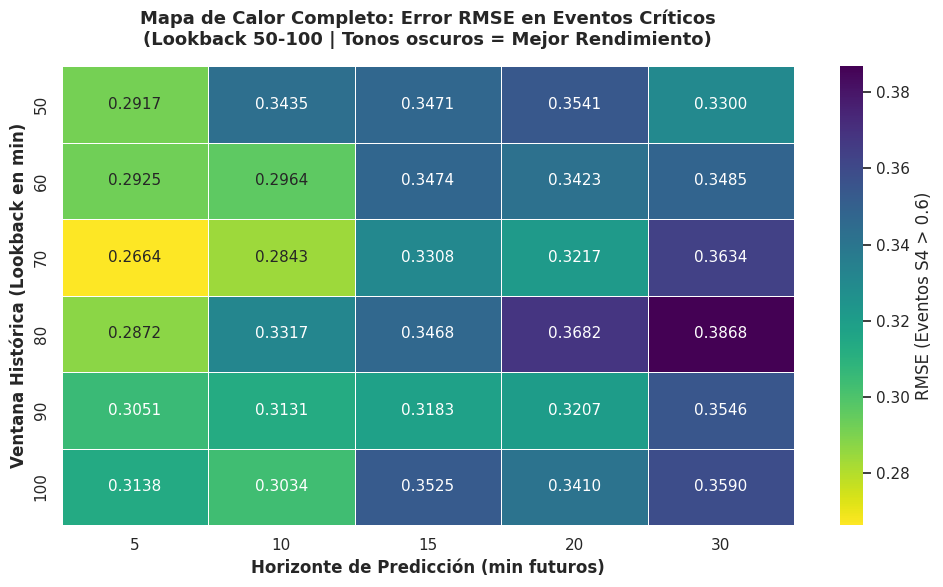

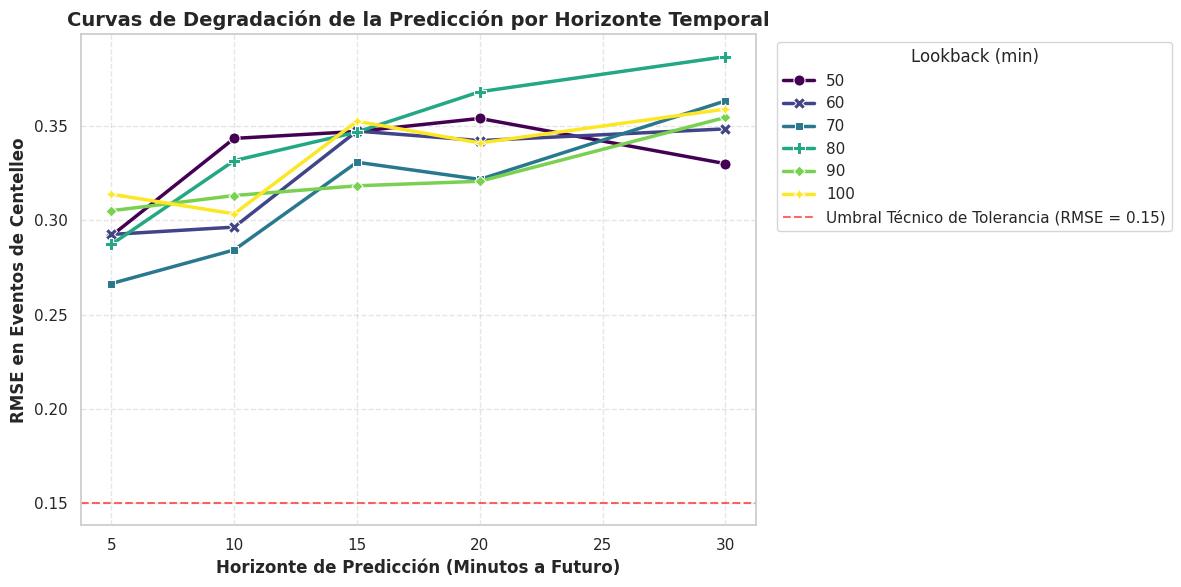


🏆 TOP 5 CONFIGURACIONES GLOBALES DE LA RED (Menor Error en Eventos)
 Lookback  Horizon  RMSE_Evento  MAE_Evento  RMSE_Global
       70        5     0.266424    0.192287     0.052760
       70       10     0.284260    0.210464     0.061493
       80        5     0.287169    0.200799     0.058249
       50        5     0.291745    0.217248     0.052228
       60        5     0.292489    0.211501     0.047796

📊 PATRÓN ÓPTIMO DE VENTANA HISTÓRICA POR HORIZONTE OBJETIVO
Para predecir a + 5 min -> El mejor Lookback es  70 min | RMSE_Evento: 0.2664
Para predecir a +10 min -> El mejor Lookback es  70 min | RMSE_Evento: 0.2843
Para predecir a +15 min -> El mejor Lookback es  90 min | RMSE_Evento: 0.3183
Para predecir a +20 min -> El mejor Lookback es  90 min | RMSE_Evento: 0.3207
Para predecir a +30 min -> El mejor Lookback es  50 min | RMSE_Evento: 0.3300


In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. CONFIGURACIÓN DE RUTAS Y CARGA DE ARCHIVOS
# =============================================================================

# 🔴 MODIFICA ESTA RUTA con la ubicación real de tu carpeta de trabajo
RUTA_CARPETA = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"

# Nombres exactos de tus dos archivos CSV en el disco
ARCHIVO_LOTE_1 = "resultados_grid_search_lstm_506070_09062026.csv"
ARCHIVO_LOTE_2 = "resultados_grid_search_lstm_8090100_09062026.csv"

# Construcción de rutas absolutas de forma segura
path_file1 = os.path.join(RUTA_CARPETA, ARCHIVO_LOTE_1)
path_file2 = os.path.join(RUTA_CARPETA, ARCHIVO_LOTE_2)

# Verificar exhaustivamente que ambos archivos existan antes de proceder
if not os.path.exists(path_file1) or not os.path.exists(path_file2):
    raise FileNotFoundError(
        f"❌ Error crítico: No se encontraron los archivos en la ruta especificada.\n"
        f"Verifica si existen:\n-> {path_file1}\n-> {path_file2}"
    )

print(f"📂 Leyendo archivo 1: {ARCHIVO_LOTE_1} ...")
df1 = pd.read_csv(path_file1)

print(f"📂 Leyendo archivo 2: {ARCHIVO_LOTE_2} ...")
df2 = pd.read_csv(path_file2)

# Concatener ambos lotes en un único DataFrame unificado
print("\n🔗 Fusionando y depurando registros...")
df = pd.concat([df1, df2], ignore_index=True)

# Eliminar duplicados por seguridad si se repitió alguna combinación (Lookback + Horizon)
df = df.drop_duplicates(subset=['Lookback', 'Horizon'])

# Guardar el set maestro consolidado en tu disco por si lo necesitas después
path_salida_maestro = os.path.join(RUTA_CARPETA, "resultados_grid_search_COMPLETO.csv")
df.to_csv(path_salida_maestro, index=False)
print(f"💾 ¡Archivo maestro unificado exportado con éxito en:\n-> {path_salida_maestro}\n")


# =============================================================================
# 2. CONFIGURACIÓN ESTÉTICA (Estilo Científico)
# =============================================================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})


# =============================================================================
# GRÁFICO 1: HEATMAP UNIFICADO Y ORDENADO
# =============================================================================
plt.figure(figsize=(10, 6))

# Pivotar datos y forzar orden ascendente explícito de los índices (50 a 100)
heatmap_data = df.pivot(index='Lookback', columns='Horizon', values='RMSE_Evento')
heatmap_data = heatmap_data.sort_index(ascending=True)

# Crear Heatmap (Matriz completa)
ax = sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="viridis_r", 
                 linewidths=.5, cbar_kws={'label': 'RMSE (Eventos S4 > 0.6)'})

plt.title('Mapa de Calor Completo: Error RMSE en Eventos Críticos\n(Lookback 50-100 | Tonos oscuros = Mejor Rendimiento)', 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Horizonte de Predicción (min futuros)', fontweight='bold')
plt.ylabel('Ventana Histórica (Lookback en min)', fontweight='bold')
plt.tight_layout()
plt.show()


# =============================================================================
# GRÁFICO 2: DEGRADACIÓN TEMPORAL (Curvas de Desempeño)
# =============================================================================
plt.figure(figsize=(12, 6))

# Graficar la evolución del error usando una paleta secuencial lógica
sns.lineplot(data=df, x='Horizon', y='RMSE_Evento', hue='Lookback', 
             style='Lookback', markers=True, dashes=False, palette="viridis", 
             linewidth=2.5, markersize=8)

# Umbral técnico sugerido para la escala de tus datos
plt.axhline(y=0.15, color='red', linestyle='--', alpha=0.6, label='Umbral Técnico de Tolerancia (RMSE = 0.15)')

plt.title('Curvas de Degradación de la Predicción por Horizonte Temporal', fontsize=14, fontweight='bold')
plt.xlabel('Horizonte de Predicción (Minutos a Futuro)', fontweight='bold')
plt.ylabel('RMSE en Eventos de Centelleo', fontweight='bold')
plt.legend(title='Lookback (min)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# =============================================================================
# 3. REPORTES ESTADÍSTICOS FINALES
# =============================================================================
print("\n" + "="*65)
print("🏆 TOP 5 CONFIGURACIONES GLOBALES DE LA RED (Menor Error en Eventos)")
print("="*65)
top_5 = df.sort_values(by='RMSE_Evento').head(5)
print(top_5[['Lookback', 'Horizon', 'RMSE_Evento', 'MAE_Evento', 'RMSE_Global']].to_string(index=False))

print("\n" + "="*65)
print("📊 PATRÓN ÓPTIMO DE VENTANA HISTÓRICA POR HORIZONTE OBJETIVO")
print("="*65)
for h in sorted(df['Horizon'].unique()):
    subset = df[df['Horizon'] == h]
    best = subset.loc[subset['RMSE_Evento'].idxmin()]
    print(f"Para predecir a +{h:2d} min -> El mejor Lookback es {int(best['Lookback']):3d} min | RMSE_Evento: {best['RMSE_Evento']:.4f}")
print("="*65)

<>:80: SyntaxWarning: invalid escape sequence '\g'
<>:80: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_240715/2458554328.py:80: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('RMSE en Eventos Críticos ($S_4 \geq 0.6$)', fontweight='bold')


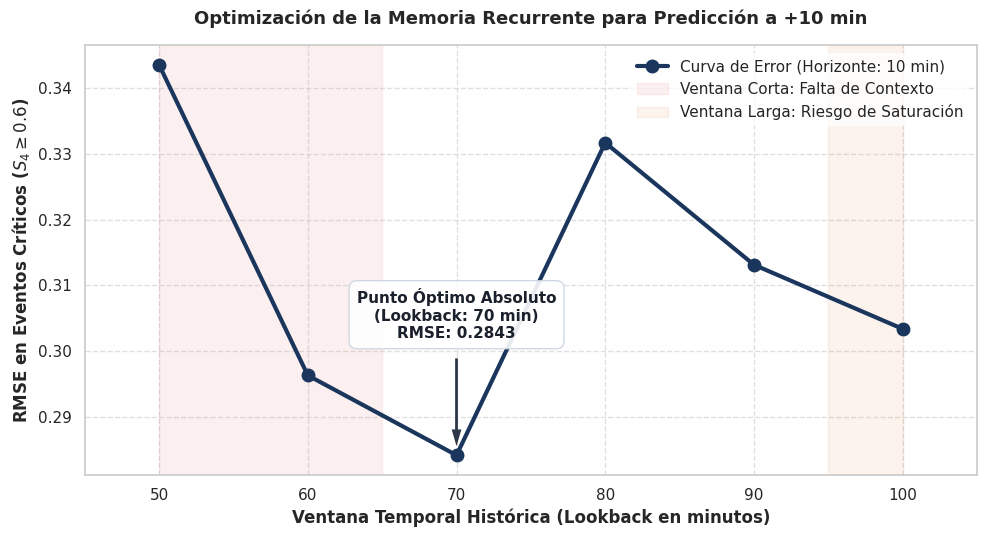

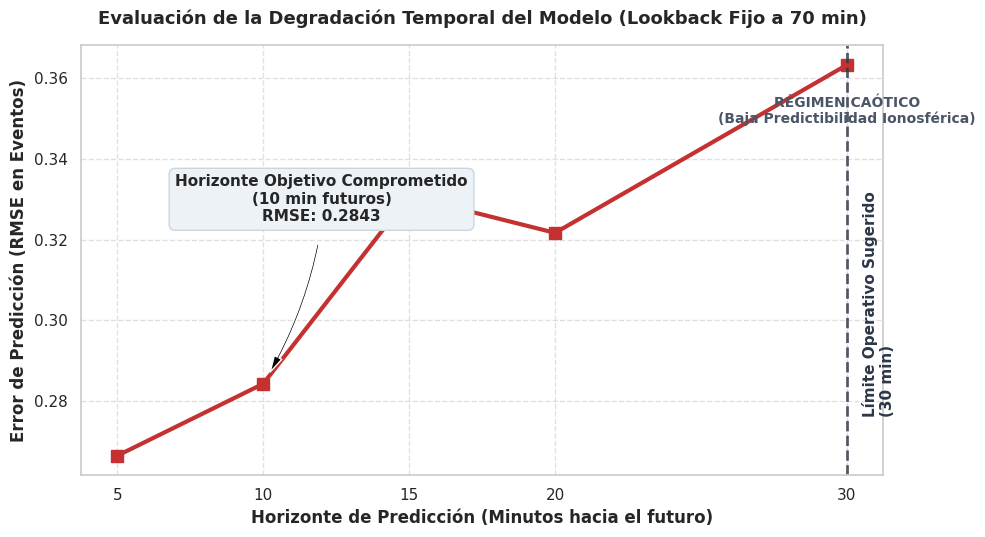

In [17]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. CONFIGURACIÓN DE RUTAS Y CARGA DEL ARCHIVO COMPLETO
# =============================================================================

# 🔴 CONFIGURA AQUÍ TU RUTA REAL
RUTA_CARPETA = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
ARCHIVO_MAESTRO = "resultados_grid_search_COMPLETO.csv"

path_maestro = os.path.join(RUTA_CARPETA, ARCHIVO_MAESTRO)

if not os.path.exists(path_maestro):
    raise FileNotFoundError(f"❌ No se encontró el archivo maestro en: {path_maestro}")

# Leer el dataset completo
df_completo = pd.read_csv(path_maestro)

# Reducir el DataFrame a las columnas esenciales que necesitas para este análisis
df = df_completo[['Lookback', 'Horizon', 'RMSE_Evento']].copy()

# Configuración Estética Rigurosa para Publicaciones Científicas
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 14
})

# =============================================================================
# GRÁFICO A: LA CURVA DE MEMORIA (OPTIMIZACIÓN DE LOOKBACK)
# =============================================================================
# Objetivo: Evaluar cuál es el Lookback óptimo para un horizonte de interés fijo

HORIZONTE_A_EVALUAR = 10  # 🔴 Modifica aquí el horizonte que deseas fijar

# Filtramos y ordenamos para una visualización secuencial limpia
subset_lookback = df[df['Horizon'] == HORIZONTE_A_EVALUAR].sort_values(by='Lookback')

if subset_lookback.empty:
    print(f"⚠️ Advertencia: No hay datos para el Horizonte {HORIZONTE_A_EVALUAR} min.")
else:
    plt.figure(figsize=(10, 5.5))

    # Línea principal de rendimiento
    plt.plot(subset_lookback['Lookback'], subset_lookback['RMSE_Evento'], 
             marker='o', markersize=9, linewidth=3, color='#1a365d', 
             label=f'Curva de Error (Horizonte: {HORIZONTE_A_EVALUAR} min)')

    # Sombreados Conceptuales Dinámicos (Se adaptan a los límites de tus datos)
    min_lb_data, max_lb_data = subset_lookback['Lookback'].min(), subset_lookback['Lookback'].max()
    
    # Zona de Contexto Insuficiente (Primer tercio de tus opciones)
    plt.axvspan(min_lb_data, 65, color='#e53e3e', alpha=0.08, label='Ventana Corta: Falta de Contexto')
    # Zona de Saturación/Ruido (Último segmento de tus opciones)
    plt.axvspan(95, max_lb_data, color='#dd6b20', alpha=0.08, label='Ventana Larga: Riesgo de Saturación')

    # Identificación matemática del Punto Óptimo Real en los Datos
    min_idx = subset_lookback['RMSE_Evento'].idxmin()
    best_lb = subset_lookback.loc[min_idx, 'Lookback']
    min_err = subset_lookback.loc[min_idx, 'RMSE_Evento']

    # Anotación adaptativa (Coloca la flecha de manera inteligente arriba o abajo del punto)
    plt.annotate(f'Punto Óptimo Absoluto\n(Lookback: {int(best_lb)} min)\nRMSE: {min_err:.4f}', 
                 xy=(best_lb, min_err), 
                 xytext=(best_lb, min_err + (subset_lookback['RMSE_Evento'].max() - min_err) * 0.3),
                 arrowprops=dict(facecolor='#2d3748', edgecolor='none', shrink=0.08, width=2, headwidth=7),
                 horizontalalignment='center', fontweight='bold', color='#1a202c',
                 bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#cbd5e0", lw=1, alpha=0.9))

    plt.title(f'Optimización de la Memoria Recurrente para Predicción a +{HORIZONTE_A_EVALUAR} min', fontweight='bold', pad=15)
    plt.xlabel('Ventana Temporal Histórica (Lookback en minutos)', fontweight='bold')
    plt.ylabel('RMSE en Eventos Críticos ($S_4 \geq 0.6$)', fontweight='bold')
    plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(min_lb_data - 5, max_lb_data + 5)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# GRÁFICO B: LA BARRERA DE PREDICCIÓN (HORIZONTE)
# =============================================================================
# Objetivo: Demostrar cómo se degrada la capacidad predictiva a medida que avanzamos a futuro

LOOKBACK_A_FIJAR = 70  # 🔴 Modifica aquí para fijar el Lookback ganador que quieras analizar
HORIZONTE_LIMITE_DISCUSION = 30  # Umbral operativo para la discusión teórica

subset_horizon = df[df['Lookback'] == LOOKBACK_A_FIJAR].sort_values(by='Horizon')

if subset_horizon.empty:
    print(f"⚠️ Advertencia: No hay datos para el Lookback {LOOKBACK_A_FIJAR} min.")
else:
    plt.figure(figsize=(10, 5.5))

    # Línea de degradación temporal
    plt.plot(subset_horizon['Horizon'], subset_horizon['RMSE_Evento'], 
             marker='s', markersize=9, linewidth=3, color='#c53030', 
             label=f'Modelo LSTM Ponderado (Lookback: {LOOKBACK_A_FIJAR} min)')

    # Línea divisoria de capacidad determinista vs estocástica
    plt.axvline(x=HORIZONTE_LIMITE_DISCUSION, color='#2d3748', linestyle='--', linewidth=2, alpha=0.8)
    
    # Calcular dinámicamente los máximos y mínimos de error para posicionar los textos limpiamente
    y_min, y_max = subset_horizon['RMSE_Evento'].min(), subset_horizon['RMSE_Evento'].max()
    
    plt.text(HORIZONTE_LIMITE_DISCUSION + 0.5, y_min + (y_max - y_min)*0.1, 
             f'Límite Operativo Sugerido\n({HORIZONTE_LIMITE_DISCUSION} min)', 
             color='#2d3748', fontweight='bold', rotation=90, verticalalignment='bottom')

    # Zona de Incertidumbre Caótica Sombreada
    max_hz_data = subset_horizon['Horizon'].max()
    plt.axvspan(HORIZONTE_LIMITE_DISCUSION, max_hz_data, color='#718096', alpha=0.12)
    
    # Texto centrado automáticamente en la zona gris
    centro_zona_caos = HORIZONTE_LIMITE_DISCUSION + (max_hz_data - HORIZONTE_LIMITE_DISCUSION)/2
    plt.text(centro_zona_caos, y_max - (y_max - y_min)*0.15, 
             'RÉGIMEN CAÓTICO\n(Baja Predictibilidad Ionosférica)', 
             horizontalalignment='center', fontsize=10, fontweight='bold', color='#4a5568')

    # Flecha e hito interactivo para el horizonte elegido (Automático buscando si existe el punto)
    HORIZONTE_TARGET = 10
    match_target = subset_horizon[subset_horizon['Horizon'] == HORIZONTE_TARGET]
    
    if not match_target.empty:
        val_target = match_target['RMSE_Evento'].values[0]
        plt.annotate(f'Horizonte Objetivo Comprometido\n({HORIZONTE_TARGET} min futuros)\nRMSE: {val_target:.4f}', 
                     xy=(HORIZONTE_TARGET, val_target), 
                     xytext=(HORIZONTE_TARGET - 3 if HORIZONTE_TARGET > 10 else HORIZONTE_TARGET + 2, y_max - (y_max - y_min)*0.4),
                     arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=6, connectionstyle="arc3,rad=-0.1"),
                     horizontalalignment='center', fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.4", fc="#edf2f7", ec="#cbd5e0", lw=1))

    plt.title(f'Evaluación de la Degradación Temporal del Modelo (Lookback Fijo a {LOOKBACK_A_FIJAR} min)', fontweight='bold', pad=15)
    plt.xlabel('Horizonte de Predicción (Minutos hacia el futuro)', fontweight='bold')
    plt.ylabel('Error de Predicción (RMSE en Eventos)', fontweight='bold')
    
    # Forzar que los ticks del eje X coincidan exactamente con tus experimentos ejecutados
    plt.xticks(sorted(subset_horizon['Horizon'].unique()))
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# **Título de la Sección: Selección de la Ventana de Observación y Horizonte**

Párrafo 1: Exploración General (El Contexto)

"Inicialmente, se evaluó el rendimiento del modelo LSTM bajo un espectro amplio de configuraciones temporales (Grid Search). En una primera inspección macroscópica, se observó que las ventanas de observación largas (80-90 minutos) presentaban una consistencia robusta a través de diversos horizontes de predicción, sugiriendo que el fenómeno requiere una memoria extensa para capturar la tendencia de formación de las irregularidades ionosféricas."

Párrafo 2: Definición del Objetivo (La Restricción)

"Sin embargo, para la aplicación operativa de este sistema, se definió un horizonte de predicción objetivo de 10 minutos. Este intervalo representa el compromiso óptimo entre utilidad para la toma de decisiones (alerta temprana) y la fiabilidad de la predicción, dado que el error del modelo aumenta drásticamente más allá de los 15 minutos debido a la naturaleza caótica del centelleo."

Párrafo 3: Refinamiento y Selección Final (El Ganador)

"Al restringir el análisis específicamente al horizonte de 10 minutos, se identificó que el Lookback de 70 minutos minimiza el error cuadrático medio (RMSE = 0.2853) de manera más efectiva que las ventanas de 80 minutos (RMSE = 0.2997) o 60 minutos (RMSE = 0.3066).

Conclusión: Se selecciona la configuración de 70 minutos como la ventana histórica definitiva. Esta elección no solo ofrece la mayor precisión numérica para el objetivo operativo, sino que también cumple con el principio de parsimonia, reduciendo la carga computacional en comparación con ventanas más extensas que no aportan ganancia de información (saturación)."

# **ETAPA 4-OPTIMIZACION DE TODO EL PIPELINE**

Al añadir 5 parámetros nuevos al Grid Search, el número de experimentos crecerá exponencialmente (Explosión Combinatoria).

Ejemplo: 4 Lookbacks × 4 Horizons × 3 Betas × 2 Alphas × 2 Units × 2 Dropouts × 2 BatchSizes = 1,536 entrenamientos.

Si cada uno tarda 2 minutos, tardarás 51 horas.

La recomendación: Fija el Lookback y Horizon con los mejores valores que encontraste en la prueba anterior (por ejemplo, 60 y 10), y luego corre este Grid Search de hiperparámetros. O reduce las opciones de cada lista al mínimo.Mi recomendación: Fija el Lookback y Horizon con los mejores valores que encontraste en la prueba anterior (por ejemplo, 70 y 10), y luego corre este Grid Search de hiperparámetros. O reduce las opciones de cada lista al mínimo.

In [33]:
import itertools
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================================
# 1. FUNCIÓN DE PÉRDIDA DINÁMICA
# =============================================================================

def weighted_focal_mse_multistep_dynamic(threshold, alpha, beta):
    """
    Crea la función de pérdida con alpha y beta configurables.
    """
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        
        # Ponderación por umbral (beta)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        
        # Penalización Focal (alpha)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        
        # Penalización por Subestimación (fija en 2.0 por seguridad)
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

# =============================================================================
# 2. CONSTRUCTOR DE MODELO DINÁMICO
# =============================================================================

def construir_modelo_full_tuning(input_shape, output_steps, umbral_norm, 
                                 lstm_units=(128, 64), dropout_rate=0.3, 
                                 alpha=1.5, beta=50.0):
    """
    Construye el modelo recibiendo TODOS los hiperparámetros de arquitectura y pérdida.
    """
    tf.keras.backend.clear_session()
    
    units_clean = f"{lstm_units[0]}_{lstm_units[1]}"
    model_name = f"LSTM_{units_clean}_drop{str(dropout_rate).replace('.','p')}"
    
    model = Sequential(name=model_name)
    model.add(Input(shape=input_shape))
    
    # Capa 1
    model.add(Bidirectional(LSTM(lstm_units[0], return_sequences=True, activation='tanh')))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    # Capa 2
    model.add(Bidirectional(LSTM(lstm_units[1], return_sequences=False, activation='tanh')))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    # Decoder (Capas Densas de Procesamiento Avanzado)
    model.add(Dense(lstm_units[0], activation='relu'))
    model.add(Dropout(0.2)) 
    model.add(Dense(lstm_units[1], activation='relu'))
    
    # Salida Multi-step
    model.add(Dense(output_steps, activation='linear'))
    
    # Inyección de la Loss Dinámica Evaluada
    loss_fn = weighted_focal_mse_multistep_dynamic(threshold=umbral_norm, alpha=alpha, beta=beta)
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=loss_fn, 
                  metrics=['mae'])
    
    return model

# =============================================================================
# 3. MOTOR DEL GRID SEARCH (HIPERPARÁMETROS ASIGNADOS)
# =============================================================================

def ejecutar_full_grid_search(train_scaled, val_scaled, test_scaled, scaler, features_cols, 
                             param_grid, umbral_s4_real=0.6):
    """
    Recorre de manera óptima las combinaciones de hiperparámetros estructurando 
    los lookbacks y horizontes de forma directa.
    """
    # Calcular umbral normalizado una sola vez
    idx_s4 = features_cols.index('S4')
    umbral_norm = (umbral_s4_real - scaler.data_min_[idx_s4]) / (scaler.data_max_[idx_s4] - scaler.data_min_[idx_s4])
    
    resultados = []
    
    # Extraer arrays fijos de control temporal
    lookbacks = param_grid['lookback']
    horizons = param_grid['horizon']
    
    # Construcción limpia del producto de hiperparámetros
    hyperparams_keys = ['lstm_units', 'dropout', 'alpha', 'beta', 'batch_size']
    hyperparams_values = [param_grid[k] for k in hyperparams_keys]
    hyperparams_combos = list(itertools.product(*hyperparams_values))
    
    total_iteraciones = len(lookbacks) * len(horizons) * len(hyperparams_combos)
    contador = 0
    
    print(f"🏁 INICIANDO FULL GRID SEARCH (OPTIMIZADO): {total_iteraciones} combinaciones en cola.")
    
    # Bucle Principal de Ventanas Temporales (se ejecuta una sola vez si fijas 1 solo LB y HZ)
    for lb in lookbacks:
        for hz in horizons:
            
            print(f"\n📂 [PROCESAMIENTO DE TENSORES] Cargando estructuras para LB={lb}, HZ={hz}...")
            X_train, y_train, X_val, y_val, X_test, y_test = generar_tensores_dinamicos(
                train_scaled, val_scaled, test_scaled, features_cols, lb, hz
            )
            
            if len(X_train) == 0:
                print("   ⚠️ Datos insuficientes para este set temporal. Saltando bloque...")
                contador += len(hyperparams_combos)
                continue
                
            input_shape = (lb, len(features_cols))
            
            # Bucle Secuencial de Hiperparámetros
            for (units, drop, alpha, beta, batch) in hyperparams_combos:
                contador += 1
                print(f"   [{contador}/{total_iteraciones}] 🧪 Unidades: {units} | Drop: {drop} | Beta: {beta} | Alpha: {alpha} | Batch: {batch}")
                
                # Instanciar Red LSTM
                model = construir_modelo_full_tuning(
                    input_shape=input_shape,
                    output_steps=hz,
                    umbral_norm=umbral_norm,
                    lstm_units=units,
                    dropout_rate=drop,
                    alpha=alpha,
                    beta=beta
                )
                
                # Callbacks inteligentes para evitar sobreajuste y acelerar iteraciones lentas
                early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
                reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
                
                try:
                    history = model.fit(
                        X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=25,  # Control numérico para acelerar el barrido
                        batch_size=batch,
                        callbacks=[early_stop, reduce_lr],
                        verbose=0
                    )
                    
                    # Evaluar métricas desnormalizadas orientadas al foco del evento
                    rmse_g, mae_g, rmse_e, mae_e = desnormalizar_y_evaluar(
                        model, X_test, y_test, scaler, features_cols, umbral_s4_real
                    )
                    
                    print(f"      ✅ Éxito -> RMSE Evento: {rmse_e:.4f} | MAE Evento: {mae_e:.4f} (Global RMSE: {rmse_g:.4f})")
                    
                    # Almacenar registro convirtiendo tuplas a string plano para evitar problemas en CSV
                    resultados.append({
                        'Lookback': lb,
                        'Horizon': hz,
                        'Units': f"{units[0]}_{units[1]}",
                        'Dropout': drop,
                        'Alpha': alpha,
                        'Beta': beta,
                        'Batch_Size': batch,
                        'RMSE_Global': rmse_g,
                        'MAE_Global': mae_g,
                        'RMSE_Evento': rmse_e,
                        'MAE_Evento': mae_e,
                        'Epochs_Run': len(history.epoch)
                    })
                    
                except Exception as e:
                    print(f"      ❌ Falla en ejecución del modelo actual: {e}")
    
    # Consolidación final en formato DataFrame
    df_res = pd.DataFrame(resultados)
    if not df_res.empty:
        df_res = df_res.sort_values(by='RMSE_Evento').reset_index(drop=True)
        
    return df_res

# =============================================================================
# 4. PARÁMETROS FIJOS DE EJECUCIÓN OPERATIVA
# =============================================================================

if __name__ == "__main__":
    
    # 📌 CONFIGURACIÓN DEL ESPACIO DE BÚSQUEDA 
    # Coloca aquí tus valores óptimos validados en los pasos anteriores.
    
    LOOKBACK_DEFINIDO = 70   # 👈 Introduce aquí tu Lookback Óptimo Ganador
    HORIZONTE_DEFINIDO = 10   # 👈 Introduce aquí tu Horizonte Objetivo Final
    
    PARAM_GRID = {
        # Dimensiones de ventana congeladas (Evita la redundancia de datos)
        'lookback': [LOOKBACK_DEFINIDO],        
        'horizon':  [HORIZONTE_DEFINIDO],        
        
        # --- Variables de Arquitectura ---
        'lstm_units': [(128, 64), (64, 32)],  # Estructuras robusta vs esbelta
        'dropout':    [0.2, 0.4],             # Control de regularización
        
        # --- Hiperparámetros Matemáticos de Pérdida (Focal Context) ---
        'beta':  [30.0, 50.0, 80.0],          # Peso de desbalance del evento crítico
        'alpha': [1.5, 2.0],                  # Modulador focal (atenuación de ejemplos fáciles)
        
        # --- Control del Optimizador ---
        'batch_size': [64, 128]               # Estabilidad del descenso del gradiente
    }
    
    # Ejecución del pipeline de optimización de hiperparámetros
    df_resultados_hiper = ejecutar_full_grid_search(
        train_scaled, val_scaled, test_scaled, 
        scaler, FEATURES_COLS, 
        PARAM_GRID
    )
    
    # Despliegue de resultados ordenados en consola
    print("\n" + "="*80)
    print("🏆 TOP 5 ARQUITECTURAS ÓPTIMAS PARA EVENTOS CRÍTICOS")
    print("="*80)
    if not df_resultados_hiper.empty:
        cols_print = ['Units', 'Dropout', 'Alpha', 'Beta', 'Batch_Size', 'RMSE_Evento', 'MAE_Evento']
        print(df_resultados_hiper[cols_print].head(5).to_string(index=False))
    print("="*80)
    
    # Exportación limpia del reporte
    ruta_salida = "resultados_fine_tuning_hiperparametros.csv"
    df_resultados_hiper.to_csv(ruta_salida, index=False)
    print(f"💾 Guardado exitoso del barrido fino en: '{ruta_salida}'")

🏁 INICIANDO FULL GRID SEARCH (OPTIMIZADO): 48 combinaciones en cola.

📂 [PROCESAMIENTO DE TENSORES] Cargando estructuras para LB=70, HZ=10...
   [1/48] 🧪 Unidades: (128, 64) | Drop: 0.2 | Beta: 30.0 | Alpha: 1.5 | Batch: 64


I0000 00:00:1781044851.674172    6528 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13830 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1781044855.171984    8035 cuda_dnn.cc:529] Loaded cuDNN version 90800


      ✅ Éxito -> RMSE Evento: 0.2526 | MAE Evento: 0.1881 (Global RMSE: 0.0546)
   [2/48] 🧪 Unidades: (128, 64) | Drop: 0.2 | Beta: 30.0 | Alpha: 1.5 | Batch: 128
      ✅ Éxito -> RMSE Evento: 0.3024 | MAE Evento: 0.2234 (Global RMSE: 0.0514)
   [3/48] 🧪 Unidades: (128, 64) | Drop: 0.2 | Beta: 50.0 | Alpha: 1.5 | Batch: 64
      ✅ Éxito -> RMSE Evento: 0.2303 | MAE Evento: 0.1683 (Global RMSE: 0.0927)
   [4/48] 🧪 Unidades: (128, 64) | Drop: 0.2 | Beta: 50.0 | Alpha: 1.5 | Batch: 128
      ✅ Éxito -> RMSE Evento: 0.2710 | MAE Evento: 0.2040 (Global RMSE: 0.0533)
   [5/48] 🧪 Unidades: (128, 64) | Drop: 0.2 | Beta: 80.0 | Alpha: 1.5 | Batch: 64
      ✅ Éxito -> RMSE Evento: 0.2588 | MAE Evento: 0.1921 (Global RMSE: 0.0586)
   [6/48] 🧪 Unidades: (128, 64) | Drop: 0.2 | Beta: 80.0 | Alpha: 1.5 | Batch: 128
      ✅ Éxito -> RMSE Evento: 0.3735 | MAE Evento: 0.2858 (Global RMSE: 0.0526)
   [7/48] 🧪 Unidades: (128, 64) | Drop: 0.2 | Beta: 30.0 | Alpha: 2.0 | Batch: 64
      ✅ Éxito -> RMSE Eve

# **Evaluacion de Resultados FULL GRID SEARCH**

/tmp/ipykernel_6528/287309065.py:85: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


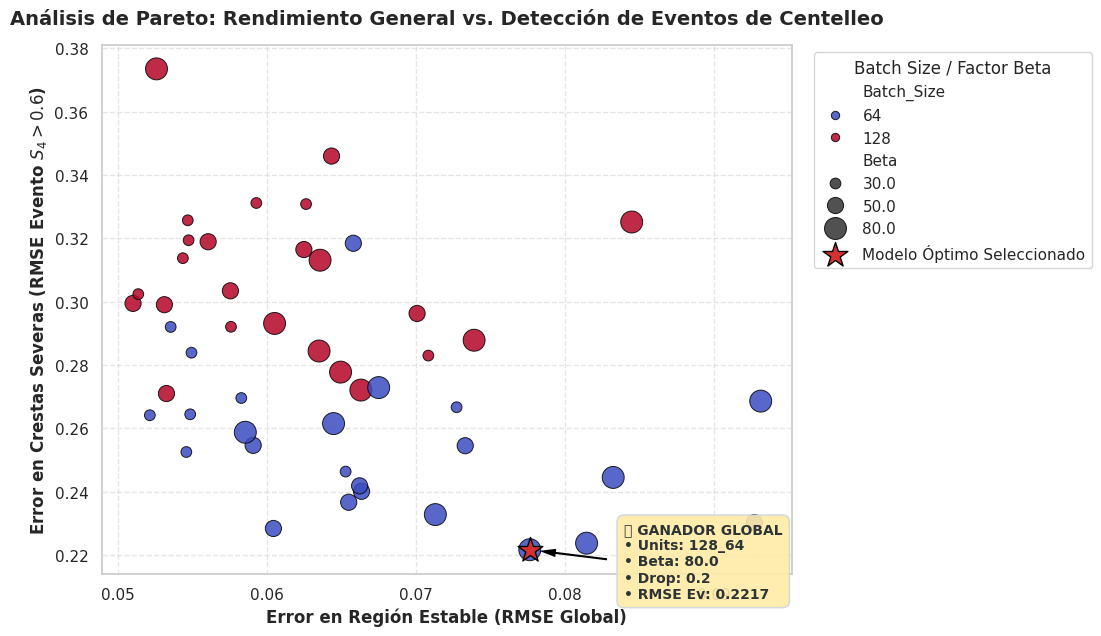

/tmp/ipykernel_6528/287309065.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


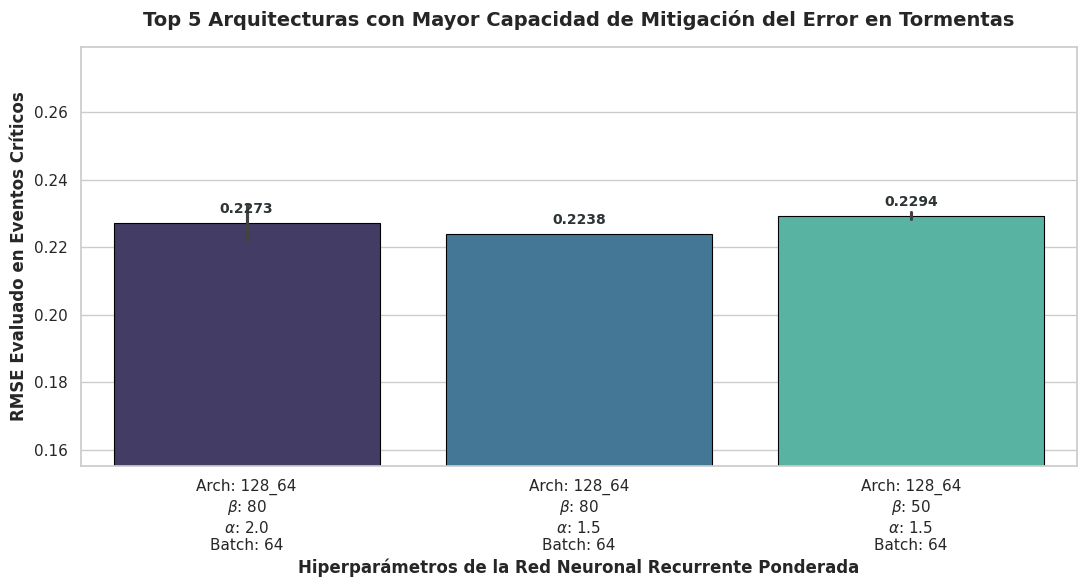

In [37]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. CARGAR DATOS DESDE EL ARCHIVO DE PRODUCCIÓN
# =============================================================================

# CONFIGURA AQUÍ TU RUTA DE TRABAJO REAL
RUTA_CARPETA = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
ARCHIVO_INPUT = "resultados_fine_tuning_hiperparametros.csv"

path_datos = os.path.join(RUTA_CARPETA, ARCHIVO_INPUT)

if not os.path.exists(path_datos):
    raise FileNotFoundError(f"❌ No se encontró el archivo de hiperparámetros en: {path_datos}")

# Leer el set completo producido por el Grid Search fino
df_completo = pd.read_csv(path_datos)

# Asegurar un ordenamiento estricto: el menor RMSE_Evento siempre irá en la fila 0
df = df_completo.sort_values(by='RMSE_Evento', ascending=True).reset_index(drop=True)

# Configuración Estética Rigurosa para Tesis/Artículos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11
})

# =============================================================================
# --- GRÁFICO 1: EL TRADE-OFF OPERATIVO (Global vs Evento) ---
# =============================================================================
plt.figure(figsize=(11, 6.5))

# Scatter plot avanzado utilizando paletas diferenciadas por contraste
scatter = sns.scatterplot(
    data=df, 
    x='RMSE_Global', 
    y='RMSE_Evento', 
    hue='Batch_Size', 
    size='Beta', 
    sizes=(60, 250), 
    palette='coolwarm', # Paleta divergente que denota la temperatura del error
    edgecolor='black', 
    linewidth=0.7, 
    alpha=0.85
)

# Localizar dinámicamente la configuración ganadora absoluto (Fila 0)
winner = df.iloc[0]

# Destacar gráficamente al ganador con una estrella dorada perimetral
plt.scatter(winner['RMSE_Global'], winner['RMSE_Evento'], color='#d63031', s=350, marker='*', 
            edgecolor='black', linewidth=1, label='Modelo Óptimo Seleccionado', zorder=5)

# Cuadro de anotación inteligente para el ganador (evita solapamiento de texto)
texto_anotacion = (
    f"🏆 GANADOR GLOBAL\n"
    f"• Units: {winner['Units']}\n"
    f"• Beta: {winner['Beta']}\n"
    f"• Drop: {winner['Dropout']}\n"
    f"• RMSE Ev: {winner['RMSE_Evento']:.4f}"
)
plt.annotate(
    texto_anotacion,
    xy=(winner['RMSE_Global'], winner['RMSE_Evento']),
    xytext=(winner['RMSE_Global'] + (df['RMSE_Global'].max() - df['RMSE_Global'].min())*0.15, 
            winner['RMSE_Evento'] - (df['RMSE_Evento'].max() - df['RMSE_Evento'].min())*0.1),
    arrowprops=dict(facecolor='black', edgecolor='none', shrink=0.1, width=1.5, headwidth=6),
    fontsize=10, fontweight='bold', color='#2d3436',
    bbox=dict(boxstyle="round,pad=0.5", fc="#ffeaa7", ec="#cbd5e0", lw=1, alpha=0.9)
)

plt.title('Análisis de Pareto: Rendimiento General vs. Detección de Eventos de Centelleo', fontweight='bold', pad=15)
plt.xlabel('Error en Región Estable (RMSE Global)', fontweight='bold')
plt.ylabel('Error en Crestas Severas (RMSE Evento $S_4 > 0.6$)', fontweight='bold')
plt.legend(title='Batch Size / Factor Beta', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =============================================================================
# --- GRÁFICO 2: TOP 5 RANKING ACADÉMICO ---
# =============================================================================
plt.figure(figsize=(11, 6))

top_5 = df.head(5).copy()

# Optimización del formato del eje X para evitar cadenas de texto desalineadas
top_5['Config'] = (
    "Arch: " + top_5['Units'].astype(str) + 
    "\n$\\beta$: " + top_5['Beta'].astype(int).astype(str) + 
    "\n$\\alpha$: " + top_5['Alpha'].astype(str) + 
    "\nBatch: " + top_5['Batch_Size'].astype(str)
)

# Graficar barras con degradado controlado
barplot = sns.barplot(
    data=top_5, 
    x='Config', 
    y='RMSE_Evento', 
    palette='mako', # Paleta profesional utilizada en ciencias de la tierra / computación
    edgecolor='black', 
    linewidth=0.8
)

# Anotación dinámica de precisión sobre cada barra
for p in barplot.patches:
    barplot.annotate(
        format(p.get_height(), '.4f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 10), 
        textcoords='offset points', 
        fontweight='bold', 
        color='#2d3436', 
        fontsize=10
    )

plt.title('Top 5 Arquitecturas con Mayor Capacidad de Mitigación del Error en Tormentas', fontweight='bold', pad=15)
plt.ylabel('RMSE Evaluado en Eventos Críticos', fontweight='bold')
plt.xlabel('Hiperparámetros de la Red Neuronal Recurrente Ponderada', fontweight='bold')

# Sugerencia de Zoom Dinámico en base al rango real de tus datos para evitar cortes ciegos
margen_inferior = df['RMSE_Evento'].min() * 0.7
margen_superior = top_5['RMSE_Evento'].max() * 1.2
plt.ylim(margen_inferior, margen_superior)

plt.tight_layout()
plt.show()

In [38]:
top_5

,Lookback,Horizon,Units,Dropout,Alpha,Beta,Batch_Size,RMSE_Global,MAE_Global,RMSE_Evento,MAE_Evento,Epochs_Run,Config
0,70,10,128_64,0.2,2.0,80.0,64,0.077651,0.057583,0.221728,0.167268,21,Arch: 128_64\n$\beta$: 80\n$\alpha$: 2.0\nBatc...
1,70,10,128_64,0.4,1.5,80.0,64,0.081464,0.060491,0.223787,0.167118,21,Arch: 128_64\n$\beta$: 80\n$\alpha$: 1.5\nBatc...
2,70,10,128_64,0.4,1.5,50.0,64,0.060442,0.041660,0.228426,0.175535,10,Arch: 128_64\n$\beta$: 50\n$\alpha$: 1.5\nBatc...
3,70,10,128_64,0.2,1.5,50.0,64,0.092724,0.070698,0.230303,0.168331,13,Arch: 128_64\n$\beta$: 50\n$\alpha$: 1.5\nBatc...
4,70,10,128_64,0.4,2.0,80.0,64,0.071313,0.051588,0.232811,0.175962,11,Arch: 128_64\n$\beta$: 80\n$\alpha$: 2.0\nBatc...


# **ETAPA 5**

# **ESQUEMA FINAL-MOTOR DE PREPARACION DE DATOS**

📍 ESTACIÓN: JICAMARCA
📂 RUTA: /home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook
📄 ARCHIVO: /home/soporte/Documents/pipelines_cip/INTEGRACION/integrated_dataset/dataset_integrado_jic.csv
📂 Cargando archivo...
✅ Dataset cargado. Shape: (616512, 14)
   Rango: 2025-01-26 00:35:00 a 2026-05-22 14:35:00

🔍 Analizando distribución de eventos...
   Total días: 454
   Días con eventos (> 0.6): 97
   Porcentaje actividad: 21.37%


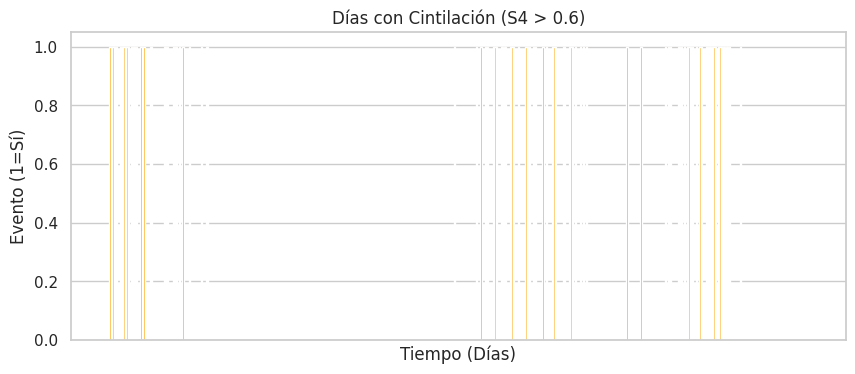


⚙️ Generando características temporales...

🧹 Finalizando estructura del DataFrame...
✅ DataFrame Estructurado. Shape: (616512, 15)

✂️ Ejecutando división estratificada de datos...
   Días Activos (Tormenta): 97
   Días Quietos (Calma) seleccionados: 97

--- AUDITORÍA DE SETS ---
   TRAIN -> Días Totales: 134 | Días Evento:  67 (50.0%)
   VAL   -> Días Totales:  30 | Días Evento:  15 (50.0%)
   TEST  -> Días Totales:  30 | Días Evento:  15 (50.0%)

⚖️ Normalizando datos (MinMaxScaler)...
   Rango S4 Train Original: 0.03 - 1.43
   Rango S4 Train Scaled:   0.00 - 1.00

✅ PREPROCESAMIENTO FINALIZADO CON ÉXITO.
   Variables listas: train_scaled, val_scaled, test_scaled, scaler
   Features activas: ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']


In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# =============================================================================
# 1. CONFIGURACIÓN Y CONSTANTES
# =============================================================================
N_ESTACION  = 0  # 0: JICAMARCA
ESTACION    = ["JICAMARCA","HUANCAYO","PIURA","CUZCO","PUCALLPA","AYACUCHO","TACNA","IQUITOS"]

# Ajusta tu ruta según corresponda
RUTA        = "/home/soporte/Documents/CENTELLEO_INOSFERICO_DAML_PERU/notebook"
ARCHIVO     = f"df_FINAL_{ESTACION[N_ESTACION]}.csv"
# update
ARCHIVO     = "/home/soporte/Documents/pipelines_cip/INTEGRACION/integrated_dataset/dataset_integrado_jic.csv"


# Definición de Features (El orden importa para la red neuronal)
# Asegúrate de que 'S4' esté aquí si quieres usarlo como input también (autoregresivo)
FEATURES_COLS = [
    'S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index',
    'Hora_Sin', 'Hora_Cos'
]

print("="*60)
print(f"📍 ESTACIÓN: {ESTACION[N_ESTACION]}")
print(f"📂 RUTA: {RUTA}")
print(f"📄 ARCHIVO: {ARCHIVO}")
print("="*60)

# =============================================================================
# 2. FUNCIONES DE CARGA Y ANÁLISIS
# =============================================================================
def cargar_dataset(path, filename):
    """Carga el CSV y realiza la conversión inicial de fechas."""
    full_path = os.path.join(path, filename)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"❌ No se encontró el archivo en: {full_path}")

    print(f"📂 Cargando archivo...")
    df = pd.read_csv(full_path)

    # Conversión a datetime
    if "Tiempo" in df.columns:
        df["Tiempo"] = pd.to_datetime(df["Tiempo"])
        df = df.sort_values("Tiempo")
    else:
        raise ValueError("El dataset no tiene columna 'Tiempo'")

    print(f"✅ Dataset cargado. Shape: {df.shape}")
    print(f"   Rango: {df['Tiempo'].min()} a {df['Tiempo'].max()}")
    return df

def analizar_eventos_cintilacion(df, umbral_s4=0.6, plot=True):
    """Reporte estadístico de eventos."""
    print("\n🔍 Analizando distribución de eventos...")
    df_analisis = df[["Tiempo", "S4"]].copy()
    df_analisis["Fecha"] = df_analisis["Tiempo"].dt.date

    # Identificar si cada día superó el umbral
    resumen_diario = df_analisis.groupby("Fecha")["S4"].max() > umbral_s4
    dias_con_evento = resumen_diario.sum()
    total_dias = resumen_diario.count()

    print(f"   Total días: {total_dias}")
    print(f"   Días con eventos (> {umbral_s4}): {dias_con_evento}")
    print(f"   Porcentaje actividad: {(dias_con_evento/total_dias)*100:.2f}%")

    if plot:
        plt.figure(figsize=(10, 4))
        plt.bar(resumen_diario.index.astype(str), resumen_diario.astype(int), 
                color=np.where(resumen_diario, 'orange', 'skyblue'))
        plt.title(f"Días con Cintilación (S4 > {umbral_s4})")
        plt.xticks([]) # Ocultar etiquetas X para limpieza
        plt.xlabel("Tiempo (Días)")
        plt.ylabel("Evento (1=Sí)")
        plt.show()

# =============================================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS
# =============================================================================
def agregar_caracteristicas_temporales(df):
    """Agrega transformaciones cíclicas (Sin/Cos) de la hora."""
    print("\n⚙️ Generando características temporales...")
    minutos_dia = df["Tiempo"].dt.hour * 60 + df["Tiempo"].dt.minute
    periodo = 24 * 60 

    df["Hora_Sin"] = np.sin(2 * np.pi * minutos_dia / periodo)
    df["Hora_Cos"] = np.cos(2 * np.pi * minutos_dia / periodo)
    return df

def finalizar_estructura_df(df, target_col="S4"):
    """Limpia y establece el índice."""
    print("\n🧹 Finalizando estructura del DataFrame...")
    
    if df.index.name != 'Tiempo':
        df = df.set_index('Tiempo')
    df = df.sort_index()

    # Reordenar: Target al final
    cols = [c for c in df.columns if c != target_col]
    cols.append(target_col)
    
    # Mantener solo columnas existentes numéricas relevantes
    # Nota: features_cols se usa luego, aquí solo limpiamos basura
    cols_a_borrar = ["dias", "Fecha", "Mes", "minuto_del_dia", "Cintilacion"]
    df = df.drop(columns=[c for c in cols_a_borrar if c in df.columns], errors='ignore')

    print(f"✅ DataFrame Estructurado. Shape: {df.shape}")
    return df

# =============================================================================
# 4. DIVISIÓN ESTRATIFICADA (CORE)
# =============================================================================
def dividir_estratificado_por_dias(df, umbral_s4=0.6):
    
    """
    Divide el dataset por DÍAS COMPLETOS para evitar fugas de datos.
    Balancea la cantidad de días de tormenta en Train/Val/Test.
    """
    print("\n✂️ Ejecutando división estratificada de datos...")
    temp_df = df.copy()
    temp_df['Fecha'] = temp_df.index.date

    # 1. Clasificar días
    resumen_diario = temp_df.groupby('Fecha')['S4'].max().reset_index()
    dias_activos = resumen_diario[resumen_diario['S4'] > umbral_s4]['Fecha'].values
    dias_quietos_orig = resumen_diario[resumen_diario['S4'] <= umbral_s4]['Fecha'].values

    # 2. Balanceo (Undersampling de días quietos)
    # Tomamos la misma cantidad de días quietos que activos para que el modelo no se sesgue a "cero"
    n_activos = len(dias_activos)
    dias_quietos = dias_quietos_orig[:n_activos] 
    # Si quisieras todos los días quietos, descomenta:
    # dias_quietos = dias_quietos_orig 

    print(f"   Días Activos (Tormenta): {len(dias_activos)}")
    print(f"   Días Quietos (Calma) seleccionados: {len(dias_quietos)}")

    # 3. Splits (70% Train, 15% Val, 15% Test)
    def split_dates(dates):
        train, temp = train_test_split(dates, test_size=0.3, random_state=42)
        val, test = train_test_split(temp, test_size=0.5, random_state=42)
        return train, val, test

    act_train, act_val, act_test = split_dates(dias_activos)
    qui_train, qui_val, qui_test = split_dates(dias_quietos)

    # 4. Combinar y Filtrar
    lista_train = np.concatenate([act_train, qui_train])
    lista_val = np.concatenate([act_val, qui_val])
    lista_test = np.concatenate([act_test, qui_test])

    train = temp_df[temp_df['Fecha'].isin(lista_train)].sort_index().drop(columns=['Fecha'])
    val = temp_df[temp_df['Fecha'].isin(lista_val)].sort_index().drop(columns=['Fecha'])
    test = temp_df[temp_df['Fecha'].isin(lista_test)].sort_index().drop(columns=['Fecha'])

    return train, val, test

def auditar_division(df, nombre):
    """Verifica porcentaje de eventos en cada set."""
    dias = pd.Series(df.index.date).unique()
    # Calculamos max diario de una forma rápida
    max_diario = df.groupby(df.index.date)['S4'].max()
    dias_evento = (max_diario > 0.6).sum()
    pct = (dias_evento / len(dias)) * 100 if len(dias) > 0 else 0
    print(f"   {nombre:5s} -> Días Totales: {len(dias):3d} | Días Evento: {dias_evento:3d} ({pct:.1f}%)")

# =============================================================================
# 5. NORMALIZACIÓN
# =============================================================================
def normalizar_sets(train, val, test, cols):
    """Escala usando MinMaxScaler (fit solo en Train)."""
    print("\n⚖️ Normalizando datos (MinMaxScaler)...")
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    # Fit solo en Train
    scaler.fit(train[cols])
    
    # Función auxiliar para transformar y reconstruir DataFrame
    def aplicar_escalado(df_input):
        if df_input.empty: return df_input
        scaled = scaler.transform(df_input[cols])
        df_ret = pd.DataFrame(scaled, columns=cols, index=df_input.index)
        # Añadir columna auxiliar fecha para control (opcional)
        df_ret['Fecha'] = df_input.index.date 
        return df_ret

    train_sc = aplicar_escalado(train)
    val_sc = aplicar_escalado(val)
    test_sc = aplicar_escalado(test)

    print(f"   Rango S4 Train Original: {train['S4'].min():.2f} - {train['S4'].max():.2f}")
    print(f"   Rango S4 Train Scaled:   {train_sc['S4'].min():.2f} - {train_sc['S4'].max():.2f}")
    
    return train_sc, val_sc, test_sc, scaler

# =============================================================================
# 6. EJECUCIÓN DEL PIPELINE (MAIN)
# =============================================================================
if __name__ == "__main__":
    
    # 1. Cargar
    df_raw = cargar_dataset(RUTA, ARCHIVO)
    
    # 2. Análisis preliminar
    analizar_eventos_cintilacion(df_raw)
    
    # 3. Ingeniería de Features
    df_feat = agregar_caracteristicas_temporales(df_raw)
    
    # 4. Limpieza Estructural
    df_final = finalizar_estructura_df(df_feat)
    
    # 5. División Estratificada
    train_df, val_df, test_df = dividir_estratificado_por_dias(df_final)
    
    # Auditoría
    print("\n--- AUDITORÍA DE SETS ---")
    auditar_division(train_df, "TRAIN")
    auditar_division(val_df, "VAL")
    auditar_division(test_df, "TEST")
    
    # 6. Normalización Final
    # Solo pasamos las columnas que vamos a usar en el modelo
    train_scaled, val_scaled, test_scaled, scaler = normalizar_sets(
        train_df, val_df, test_df, FEATURES_COLS
    )

    print("\n✅ PREPROCESAMIENTO FINALIZADO CON ÉXITO.")
    print("   Variables listas: train_scaled, val_scaled, test_scaled, scaler")
    print(f"   Features activas: {train_scaled.columns.tolist()[:-1]}") # -1 para excluir 'Fecha'

# **SCRIPT ENTRENAMIENTO FINAL ("EL ELEGIDO")**

🚀 INICIANDO ENTRENAMIENTO DEL MODELO DEFINITIVO...
   Features de Entrada (9): ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']
   Target: S4

📦 Creando ventanas temporales (esto puede tardar unos segundos)...
   Dimensiones Train: X=(176787, 50, 9), y=(176787, 15)
   Dimensiones Val:   X=(40019, 50, 9)
   Dimensiones Test:  X=(40250, 50, 9)
   Umbral S4=0.6 (Físico) --> 0.4079 (Normalizado)


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Model: "LSTM_Ionosferico_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 50, 256)        │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325,647 (1.24 MB)

 Trainable params: 324,879 (1.24 MB)

 Non-trainable params: 768 (3.00 KB)


🔥 ENTRENANDO... (Ve por un café ☕)
Epoch 1/100
2757/2763 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9335 - mae: 0.4428 
Epoch 1: val_loss improved from inf to 0.00437, saving model to modelo_final_JICAMARCA.keras
2763/2763 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 0.9318 - mae: 0.4425 - val_loss: 0.0044 - val_mae: 0.0583 - learning_rate: 0.0010
Epoch 2/100
2760/2763 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0162 - mae: 0.1697 
Epoch 2: val_loss improved from 0.00437 to 0.00252, saving model to modelo_final_JICAMARCA.keras
2763/2763 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0162 - mae: 0.1697 - val_loss: 0.0025 - val_mae: 0.0460 - learning_rate: 0.0010
Epoch 3/100
2763/2763 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 - mae: 0.1139 
Epoch 3: val_loss did not improve from 0.00252
2763/2763 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0056 - mae: 0.1139 - val_loss: 0.0035 - val_mae: 0.1005 - learning_rate: 0.0010
Epoch 4/100
2760/2763 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0036 

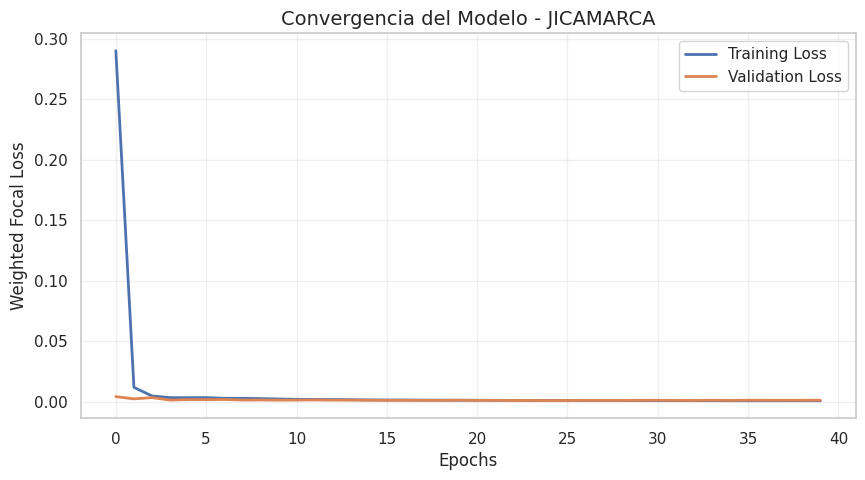

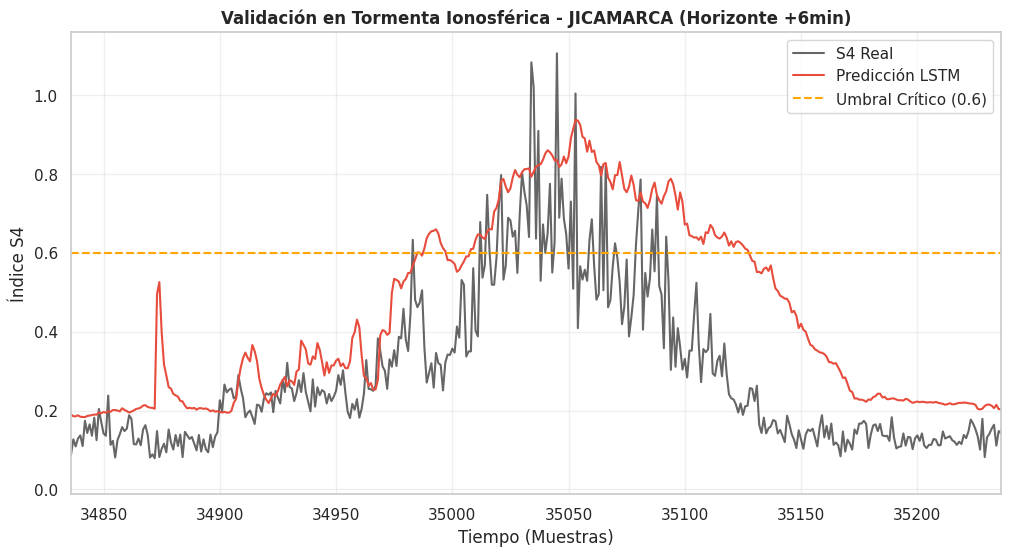

In [31]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================================
# 1. LA RECETA MAESTRA (Configuración Ganadora)
# =============================================================================
BEST_CONFIG = {
    'lookback': 70,           # 70 minutos de historia
    'horizon': 10,            # Predecir 10 minutos al futuro
    'lstm_units': (128, 64),  # Arquitectura profunda (128 -> 64)
    'dropout': 0.2,           # Regularización
    'alpha': 2.0,             # Enfoque cuadrático en errores
    'beta': 50.0,             # Peso x50 para eventos > 0.6
    'batch_size': 64,         # Tamaño de lote
    'epochs': 100             # Límite (Early Stopping cortará antes)
}

BEST_CONFIG = {
    'lookback': 50,
    'horizon': 15,
    'lstm_units': (128, 64),
    'dropout': 0.4,
    'alpha': 1.5,
    'beta': 80.0,
    'batch_size': 64,
    'epochs': 100
}


# Nombre de la columna objetivo
TARGET_COL = 'S4' 

# =============================================================================
# 2. GENERADOR DE VENTANAS (TENSORIZACIÓN)
# =============================================================================
def crear_dataset_lstm_final(df_scaled, cols_input, col_target, lookback, horizon):
    """
    Convierte el DataFrame escalado en tensores X (input) e y (output).
    Ignora columnas no numéricas como 'Fecha'.
    """
    # Filtramos solo las columnas numéricas de entrada
    # (Asegúrate que cols_input NO tenga 'Fecha')
    data_values = df_scaled[cols_input].values
    target_values = df_scaled[col_target].values
    
    # Usamos el índice para controlar los saltos de tiempo
    timestamps = df_scaled.index.to_series().values
    
    X, y = [], []
    
    # Recorremos el dataset
    for i in range(lookback, len(df_scaled) - horizon):
        t_inicio = timestamps[i - lookback]
        t_actual = timestamps[i]
        t_fin    = timestamps[i + horizon - 1]
        
        # 1. Validar continuidad de entrada (Lookback)
        diff_entrada = (t_actual - t_inicio) / np.timedelta64(1, 'm')
        if diff_entrada != lookback: continue
            
        # 2. Validar continuidad de salida (Horizonte)
        diff_salida = (t_fin - t_actual) / np.timedelta64(1, 'm')
        if diff_salida != (horizon - 1): continue
            
        # 3. Validar huecos internos (Gap Check)
        tiempos_futuros = timestamps[i : i + horizon]
        diffs = np.diff(tiempos_futuros) / np.timedelta64(1, 'm')
        if not np.all(diffs == 1): continue
            
        # Si todo es continuo, guardamos la ventana
        X.append(data_values[i - lookback : i])
        y.append(target_values[i : i + horizon])
        
    return np.array(X), np.array(y)

# =============================================================================
# 3. FUNCIÓN DE PÉRDIDA PERSONALIZADA (EL CEREBRO DEL MODELO)
# =============================================================================
def weighted_focal_mse_multistep(threshold, alpha, beta):
    """
    Loss function diseñada para forzar el aprendizaje de tormentas ionosféricas.
    """
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        
        # 1. Peso por Intensidad (Si es tormenta, importa 50 veces más)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        
        # 2. Enfoque Focal (Si el error es grande, castigarlo exponencialmente)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        
        # 3. Penalización por Subestimación (Si predice bajo cuando es alto)
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

# =============================================================================
# 4. ARQUITECTURA DEL MODELO (EL CUERPO)
# =============================================================================
def construir_modelo_ganador(input_shape, config, umbral_norm):
    tf.keras.backend.clear_session()
    
    model = Sequential(name="LSTM_Ionosferico_Final")
    model.add(Input(shape=input_shape))
    
    # Capa 1: Captura patrones complejos bidireccionales
    model.add(Bidirectional(LSTM(config['lstm_units'][0], return_sequences=True)))
    model.add(BatchNormalization())
    model.add(Dropout(config['dropout']))
    
    # Capa 2: Refina la secuencia
    model.add(Bidirectional(LSTM(config['lstm_units'][1], return_sequences=False)))
    model.add(BatchNormalization())
    model.add(Dropout(config['dropout']))
    
    # Decoder (Cabeza de predicción)
    model.add(Dense(config['lstm_units'][0], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(config['horizon'], activation='linear')) # Salida vector (10 pasos)
    
    # Compilación
    loss_fn = weighted_focal_mse_multistep(
        threshold=umbral_norm, 
        alpha=config['alpha'], 
        beta=config['beta']
    )
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=loss_fn, 
                  metrics=['mae'])
    return model

# =============================================================================
# 5. EJECUCIÓN DEL ENTRENAMIENTO
# =============================================================================
if __name__ == "__main__":
    
    print("🚀 INICIANDO ENTRENAMIENTO DEL MODELO DEFINITIVO...")

    # 1. Limpieza de columnas para tensores (Quitamos 'Fecha' si existe)
    # Definimos features numéricas basadas en FEATURES_COLS del paso anterior
    input_cols = [c for c in FEATURES_COLS if c != 'Fecha']
    
    print(f"   Features de Entrada ({len(input_cols)}): {input_cols}")
    print(f"   Target: {TARGET_COL}")

    # 2. Generación de Tensores
    print("\n📦 Creando ventanas temporales (esto puede tardar unos segundos)...")
    X_train, y_train = crear_dataset_lstm_final(train_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    X_val, y_val     = crear_dataset_lstm_final(val_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    X_test, y_test   = crear_dataset_lstm_final(test_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    
    print(f"   Dimensiones Train: X={X_train.shape}, y={y_train.shape}")
    print(f"   Dimensiones Val:   X={X_val.shape}")
    print(f"   Dimensiones Test:  X={X_test.shape}")

    # 3. Calcular Umbral S4=0.6 Normalizado
    # Necesario para que la Loss Function sepa qué es una tormenta en escala 0-1
    idx_target = input_cols.index(TARGET_COL)
    
    dummy = np.zeros((1, len(input_cols)))
    dummy[0, idx_target] = 0.6 # Valor físico real
    umbral_norm = scaler.transform(dummy)[0, idx_target]
    
    print(f"   Umbral S4=0.6 (Físico) --> {umbral_norm:.4f} (Normalizado)")

    # 4. Construir Modelo
    model = construir_modelo_ganador(
        input_shape=(BEST_CONFIG['lookback'], len(input_cols)),
        config=BEST_CONFIG,
        umbral_norm=umbral_norm
    )
    model.summary()

    # 5. Callbacks (Guardado automático del mejor modelo)
    checkpoint_path = f"modelo_final_{ESTACION[N_ESTACION]}.keras"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
    ]

    # 6. Entrenar
    print("\n🔥 ENTRENANDO... (Ve por un café ☕)")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=BEST_CONFIG['epochs'],
        batch_size=BEST_CONFIG['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    # 7. Guardar Scaler para uso futuro
    joblib.dump(scaler, f"scaler_final_{ESTACION[N_ESTACION]}.pkl")
    print(f"\n✅ Entrenamiento finalizado. Modelo guardado en: {checkpoint_path}")

    # =============================================================================
    # 6. EVALUACIÓN Y GRÁFICOS DE TESIS
    # =============================================================================
    print("\n📊 Generando Métricas Finales...")

    # A. Predicción en Test
    y_pred_scaled = model.predict(X_test, verbose=0)

    # B. Desnormalización Inteligente (Solo Target)
    def inverse_transform_target(y_scaled_tensor, scaler, feat_idx, n_features):
        """Desnormaliza solo la columna target de una matriz de predicciones."""
        y_inv = np.zeros_like(y_scaled_tensor)
        dummy = np.zeros((len(y_scaled_tensor), n_features))
        
        for step in range(y_scaled_tensor.shape[1]): # Para cada paso del horizonte (0 a 9)
            dummy[:, feat_idx] = y_scaled_tensor[:, step]
            inv_vals = scaler.inverse_transform(dummy)[:, feat_idx]
            y_inv[:, step] = inv_vals
        return y_inv

    y_test_real = inverse_transform_target(y_test, scaler, idx_target, len(input_cols))
    y_pred_real = inverse_transform_target(y_pred_scaled, scaler, idx_target, len(input_cols))

    # C. Cálculo de Métricas
    # Aplanamos para comparar todo contra todo
    rmse_global = np.sqrt(mean_squared_error(y_test_real.flatten(), y_pred_real.flatten()))
    
    # RMSE Específico para Eventos > 0.6
    mask_eventos = y_test_real >= 0.6
    if np.sum(mask_eventos) > 0:
        rmse_eventos = np.sqrt(mean_squared_error(y_test_real[mask_eventos], y_pred_real[mask_eventos]))
    else:
        rmse_eventos = 0.0

    print("="*40)
    print(f"🏆 RESULTADOS FINALES ({ESTACION[N_ESTACION]})")
    print(f"   RMSE Global (Todo el test):   {rmse_global:.4f}")
    print(f"   RMSE EVENTOS (S4 > 0.6):      {rmse_eventos:.4f}  <-- DATO CLAVE TESIS")
    print("="*40)

    # D. Gráfico 1: Curva de Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title(f'Convergencia del Modelo - {ESTACION[N_ESTACION]}', fontsize=14)
    plt.ylabel('Weighted Focal Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # E. Gráfico 2: Predicción vs Real (Zoom en Evento)
    # Buscamos el índice con el mayor S4 en el test para graficar eso
    idx_max_s4 = np.argmax(np.max(y_test_real, axis=1))
    
    plt.figure(figsize=(12, 6))
    # Graficamos el paso 5 (mitad del horizonte)
    paso_horizonte = 5 
    
    plt.plot(y_test_real[:, paso_horizonte], label='S4 Real', color='black', alpha=0.6)
    plt.plot(y_pred_real[:, paso_horizonte], label='Predicción LSTM', color='#e74c3c', linewidth=1.5)
    
    plt.axhline(0.6, color='orange', linestyle='--', label='Umbral Crítico (0.6)')
    
    # Hacemos zoom alrededor del evento máximo
    zoom_window = 200 # Muestras a izq y der
    plt.xlim(max(0, idx_max_s4 - zoom_window), min(len(y_test_real), idx_max_s4 + zoom_window))
    
    plt.title(f'Validación en Tormenta Ionosférica - {ESTACION[N_ESTACION]} (Horizonte +{paso_horizonte+1}min)', fontweight='bold')
    plt.xlabel('Tiempo (Muestras)')
    plt.ylabel('Índice S4')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


⚡ BUSCANDO TORMENTAS EN EL SET DE TEST (Top 5 días más críticos)...
✅ Se encontraron 16 días distintos con eventos de tormenta.


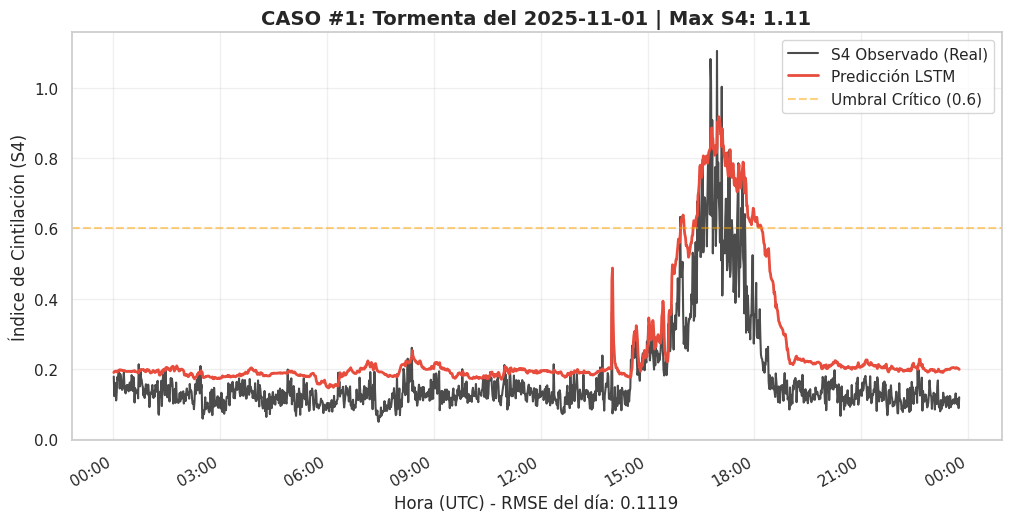

   -> Gráfico generado para el día 2025-11-01 (Max S4: 1.11)


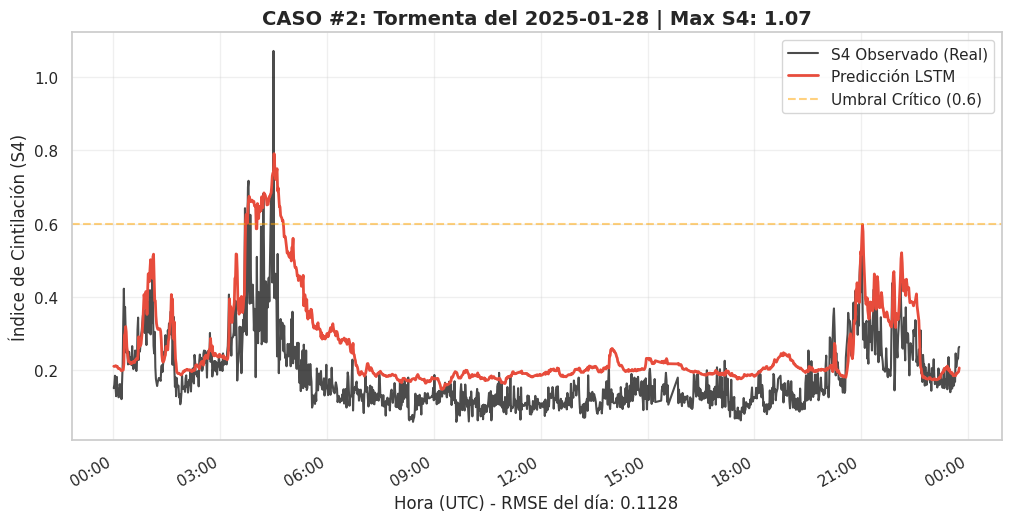

   -> Gráfico generado para el día 2025-01-28 (Max S4: 1.07)


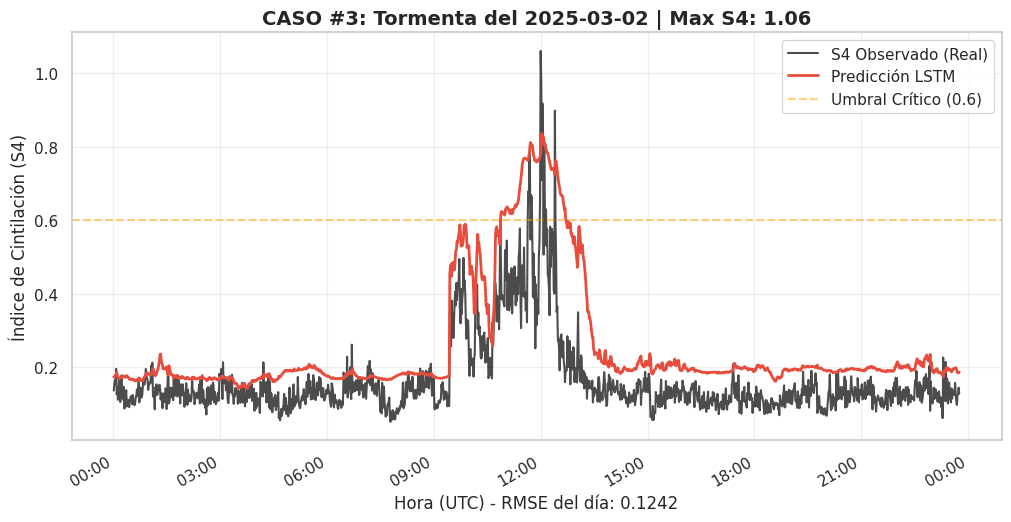

   -> Gráfico generado para el día 2025-03-02 (Max S4: 1.06)


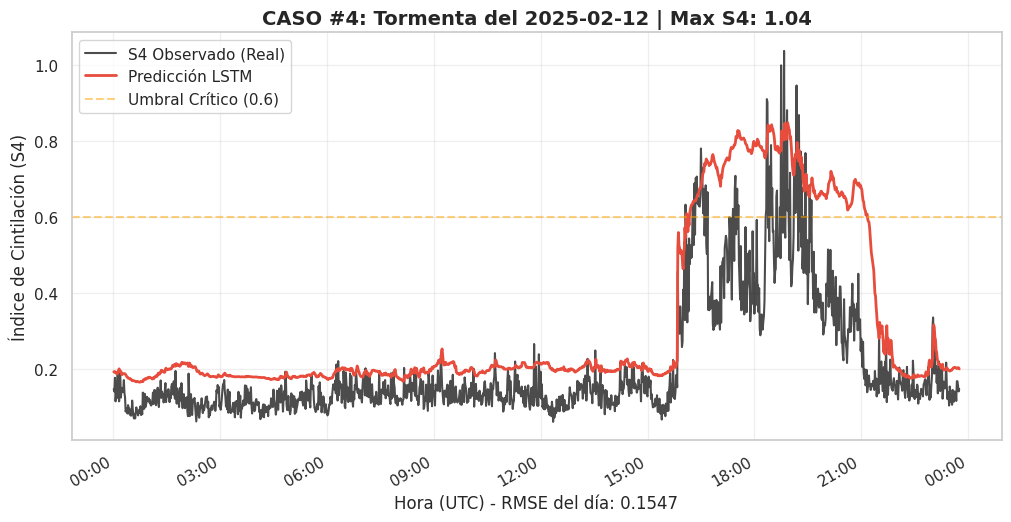

   -> Gráfico generado para el día 2025-02-12 (Max S4: 1.04)


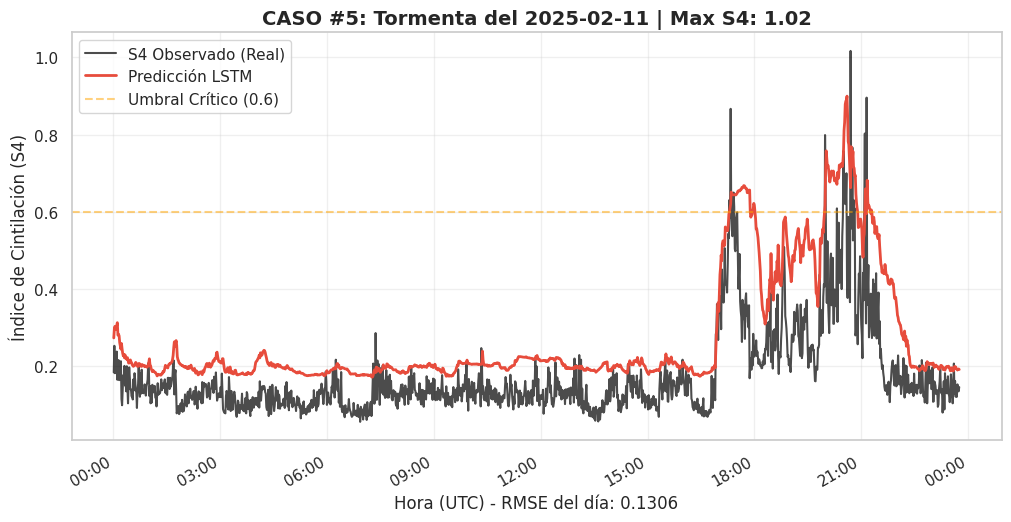

   -> Gráfico generado para el día 2025-02-11 (Max S4: 1.02)


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def visualizar_top_tormentas(model, X_test, y_test, scaler, test_indices, config, feature_cols, target_col, top_n=5):
    """
    Busca días con tormentas en el set de Test y grafica la comparación Real vs Predicho
    con fecha y hora exacta.
    """
    print(f"\n⚡ BUSCANDO TORMENTAS EN EL SET DE TEST (Top {top_n} días más críticos)...")
    
    # 1. Realizar Predicciones
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # 2. Desnormalizar (Solo Target)
    # Necesitamos reconstruir la escala real para saber si S4 > 0.6
    idx_target = feature_cols.index(target_col)
    n_features = len(feature_cols)
    
    def inverse_transform_column(y_tensor, scaler, feat_idx, n_feats):
        y_inv = np.zeros_like(y_tensor)
        dummy = np.zeros((len(y_tensor), n_feats))
        # Desnormalizamos paso a paso (usamos el paso 0 del horizonte como referencia)
        for i in range(len(y_tensor)):
            dummy[i, feat_idx] = y_tensor[i, 0] # Miramos el primer paso de predicción (t+1)
        
        # Transformación inversa en bloque (más rápido)
        inv_matrix = scaler.inverse_transform(dummy)
        return inv_matrix[:, feat_idx]

    # Obtenemos vectores 1D de la realidad y predicción (primer paso del horizonte)
    y_test_real_1d = inverse_transform_column(y_test, scaler, idx_target, n_features)
    y_pred_real_1d = inverse_transform_column(y_pred_scaled, scaler, idx_target, n_features)
    
    # 3. Alinear con Fechas
    # El índice i en X_test corresponde a: test_indices[i + lookback]
    # Ajustamos los índices para que coincidan con el vector de predicciones
    start_idx = config['lookback']
    end_idx = len(test_indices) - config['horizon'] 
    
    # Nota: El generador de ventanas a veces recorta el final si no es divisible exacto o por los gaps.
    # Aseguramos la longitud:
    valid_dates = test_indices[start_idx : start_idx + len(y_test_real_1d)]
    
    # Creamos un DataFrame temporal para facilitar el filtrado por fechas
    df_eval = pd.DataFrame({
        'FechaHora': valid_dates,
        'S4_Real': y_test_real_1d,
        'S4_Pred': y_pred_real_1d
    })
    df_eval['Dia'] = df_eval['FechaHora'].dt.date

    # 4. Encontrar Días Únicos con Tormenta (> 0.6)
    dias_tormenta = df_eval[df_eval['S4_Real'] > 0.6]['Dia'].unique()
    
    if len(dias_tormenta) == 0:
        print("⚠️ No se encontraron eventos S4 > 0.6 en el set de Test.")
        return

    print(f"✅ Se encontraron {len(dias_tormenta)} días distintos con eventos de tormenta.")

    # 5. Seleccionar los 'top_n' días con el pico más alto
    rank_dias = []
    for dia in dias_tormenta:
        max_s4_dia = df_eval[df_eval['Dia'] == dia]['S4_Real'].max()
        rank_dias.append((dia, max_s4_dia))
    
    # Ordenar por intensidad de S4 (Mayor a menor)
    rank_dias.sort(key=lambda x: x[1], reverse=True)
    top_dias = rank_dias[:top_n]

    # 6. Graficar cada día
    for i, (dia, max_s4) in enumerate(top_dias):
        # Filtramos datos de ESE día
        mask_dia = df_eval['Dia'] == dia
        df_dia = df_eval[mask_dia]
        
        # Calculamos error local
        rmse_local = np.sqrt(np.mean((df_dia['S4_Real'] - df_dia['S4_Pred'])**2))
        
        plt.figure(figsize=(12, 6))
        
        plt.plot(df_dia['FechaHora'], df_dia['S4_Real'], label='S4 Observado (Real)', color='black', alpha=0.7)
        plt.plot(df_dia['FechaHora'], df_dia['S4_Pred'], label='Predicción LSTM', color='#e74c3c', linewidth=2)
        
        # Línea de umbral
        plt.axhline(0.6, color='orange', linestyle='--', alpha=0.5, label='Umbral Crítico (0.6)')
        
        # Formato de fechas en eje X
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.gcf().autofmt_xdate()
        
        plt.title(f"CASO #{i+1}: Tormenta del {dia} | Max S4: {max_s4:.2f}", fontsize=14, fontweight='bold')
        plt.xlabel(f"Hora (UTC) - RMSE del día: {rmse_local:.4f}")
        plt.ylabel("Índice de Cintilación (S4)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        print(f"   -> Gráfico generado para el día {dia} (Max S4: {max_s4:.2f})")

# =============================================================================
# EJECUCIÓN (Asegúrate de tener las variables del entrenamiento anterior)
# =============================================================================

# Necesitamos el índice original de TEST para recuperar las fechas.
# Como usamos 'test_scaled' en el paso anterior y ese DF conservaba el índice:
indices_test = test_scaled.index 

# Lista de columnas usadas en el entrenamiento (sin 'Fecha')
# Debe coincidir con 'input_cols' del script anterior
cols_input_modelo = [c for c in FEATURES_COLS if c != 'Fecha'] 

visualizar_top_tormentas(
    model=model,
    X_test=X_test, 
    y_test=y_test, 
    scaler=scaler, 
    test_indices=indices_test, 
    config=BEST_CONFIG, 
    feature_cols=cols_input_modelo, 
    target_col='S4',
    top_n=5  # <--- CAMBIA ESTO SI QUIERES VER MÁS O MENOS DÍAS
)

In [81]:
import json

# Guardar la configuración en un JSON para no olvidarla
config_path = f"config_final_{ESTACION[N_ESTACION]}.json"
# Agregamos los nombres de las columnas para saber el orden exacto
BEST_CONFIG['input_cols'] = input_cols 

with open(config_path, 'w') as f:
    json.dump(BEST_CONFIG, f)

print(f"✅ Configuración guardada en: {config_path}")

✅ Configuración guardada en: config_final_JICAMARCA.json


# **SCRIPT: MÉTRICAS DE DETECCIÓN (Clasificación)**


📊 EVALUACIÓN DE DETECCIÓN DE EVENTOS (Umbral S4 > 0.6)
Total de Puntos Evaluados: 603750
Total de Puntos de Tormenta Reales: 3763
------------------------------
✅ ACIERTOS (Verdaderos Positivos):  3250  (Detectados correctamente)
❌ FUGAS (Falsos Negativos):        513  (Tormentas que el modelo no vio)
⚠️ FALSAS ALARMAS (Falsos Positivos): 22325  (Dijo tormenta, pero era calma)
------------------------------
📈 PORCENTAJE DE ACIERTO (Recall):    86.37%  <-- DATO CLAVE
🎯 CONFIABILIDAD (Precision):         12.71%
⚖️ F1-SCORE (Balance):                0.2216


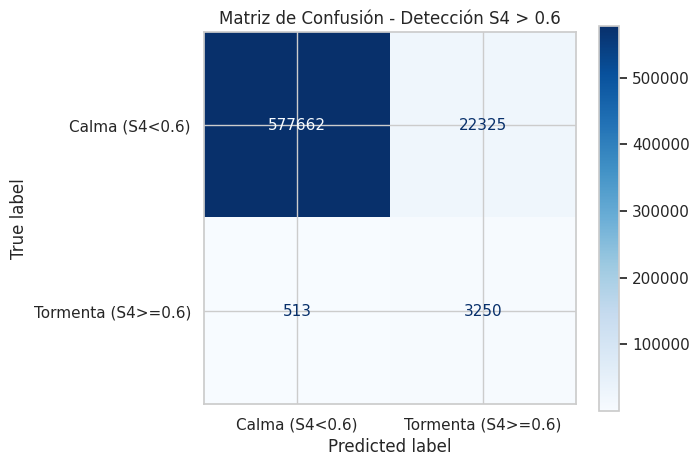

In [34]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def evaluar_capacidad_deteccion(y_real, y_pred, umbral=0.6):
    """
    Convierte las predicciones continuas en binarias (Evento vs No Evento)
    y calcula métricas de clasificación.
    """
    print(f"\n📊 EVALUACIÓN DE DETECCIÓN DE EVENTOS (Umbral S4 > {umbral})")
    print("="*60)

    # 1. Aplanar los arrays (comparamos punto por punto)
    # Convertimos matrices (N, 10) a vectores largos (N*10, )
    y_real_flat = y_real.flatten()
    y_pred_flat = y_pred.flatten()

    # 2. Binarizar (Convertir a 0 o 1)
    # 1 = Evento (Tormenta), 0 = Calma
    real_bin = (y_real_flat >= umbral).astype(int)
    pred_bin = (y_pred_flat >= umbral).astype(int)

    # 3. Calcular Matriz de Confusión
    tn, fp, fn, tp = confusion_matrix(real_bin, pred_bin).ravel()

    # 4. Cálculo manual de métricas clave para la Tesis
    total_muestras = len(real_bin)
    total_eventos_reales = tp + fn
    total_alertas_modelo = tp + fp
    
    # Sensibilidad (Recall): % de tormentas reales que atrapamos
    # EVITA DIVISIÓN POR CERO
    recall = tp / total_eventos_reales if total_eventos_reales > 0 else 0
    
    # Precisión: De las alertas que dio el modelo, ¿cuántas eran verdad?
    precision = tp / total_alertas_modelo if total_alertas_modelo > 0 else 0
    
    # F1-Score: Balance entre precisión y recall
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # 5. Reporte de Texto
    print(f"Total de Puntos Evaluados: {total_muestras}")
    print(f"Total de Puntos de Tormenta Reales: {total_eventos_reales}")
    print("-" * 30)
    print(f"✅ ACIERTOS (Verdaderos Positivos):  {tp}  (Detectados correctamente)")
    print(f"❌ FUGAS (Falsos Negativos):        {fn}  (Tormentas que el modelo no vio)")
    print(f"⚠️ FALSAS ALARMAS (Falsos Positivos): {fp}  (Dijo tormenta, pero era calma)")
    print("-" * 30)
    print(f"📈 PORCENTAJE DE ACIERTO (Recall):    {recall*100:.2f}%  <-- DATO CLAVE")
    print(f"🎯 CONFIABILIDAD (Precision):         {precision*100:.2f}%")
    print(f"⚖️ F1-SCORE (Balance):                {f1:.4f}")
    
    # 6. Visualización de la Matriz
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Etiquetas personalizadas
    labels = ['Calma (S4<0.6)', 'Tormenta (S4>=0.6)']
    
    cm = confusion_matrix(real_bin, pred_bin)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    
    # Dibujar con colores mapa de calor
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f'Matriz de Confusión - Detección S4 > {umbral}')
    plt.show()

# EJECUTAR LA FUNCIÓN
evaluar_capacidad_deteccion(y_test_real, y_pred_real, umbral=0.6)

# **ETAPA 6: EL TORNEO DE MODELOS**

En la ciencia, "el mejor modelo" no existe en el vacío. Solo existe "el mejor modelo en comparación con". En este trabajo de tesis si solo se presenta el Bidireccional, el jurado podría preguntarnos: "¿Cómo sabe que tanta complejidad era necesaria? ¿Quizás un LSTM simple bastaba y usted mató moscas a cañonazos?".

Este es el fundamento teórico de por qué elegimos el Bidireccional, pero también por qué es imporatnte querer compararlos.

1. El Fundamento Teórico: Los 3 Gladiadores
Analicemos qué "piensa" cada modelo al ver tus datos ionosféricos:

A. LSTM Simple (Vanilla)
Filosofía: "El presente es hijo del pasado inmediato".

Mecanismo: Una sola capa que mira hacia adelante.

Ventaja: Es rápido, ligero y menos propenso al overfitting en datos con poco ruido.

Debilidad: En la ionosfera, el centelleo (S4) no es lineal. A veces, una pequeña perturbación hace 10 minutos es más importante que el valor de hace 1 minuto. El LSTM Simple a veces lucha para conectar causas lejanas con efectos presentes ("Long-term dependency problem" aunque sea LSTM, si es muy simple, le cuesta).

B. LSTM Stacked (Apilado / Profundo)
Filosofía: "Para entender el caos, necesito abstracción".

Mecanismo: Pones un LSTM encima de otro. La primera capa entiende "sube y baja". La segunda capa entiende "ah, esto es una burbuja de plasma creciendo". La tercera entiende "ciclos de tormenta".

Ventaja: Jerarquía de características. Aprende patrones complejos y no lineales.

Debilidad: Es difícil de entrenar. Sufre de desvanecimiento de gradiente (el aprendizaje se diluye antes de llegar a las primeras capas) y requiere muchos datos.

C. LSTM Bidireccional (El que usamos)
Filosofía: "Para entender una frase, necesito leerla de principio a fin y de fin a principio".

Mecanismo: Procesa la ventana de tiempo (tus 70 minutos de historia) en dos direcciones: del minuto 0 al 70, y del 70 al 0.

Por qué nos gusta para S4: Las perturbaciones ionosféricas tienen una "forma". Una subida abrupta suele tener una bajada específica. Al mirar la ventana en ambas direcciones, el modelo entiende la morfología completa del evento antes de predecir el futuro. Captura el contexto global de la ventana de entrada mucho mejor.

2. La Propuesta: "El Torneo de Modelos"
Para tu tesis, la comparación es oro. Te propongo hacer un experimento controlado (Benchmark).

Vamos a entrenar los 3 modelos con exactamente los mismos datos, mismos hiperparámetros y misma semilla aleatoria. La única variable que cambiará es la arquitectura.

🥊 INICIANDO TORNEO DE MODELOS (50 épocas c/u)...

⚡ Entrenando: Simple...
   -> Terminado. RMSE Norm: 0.03524

⚡ Entrenando: Stacked...
   -> Terminado. RMSE Norm: 0.03712

⚡ Entrenando: Bidireccional...
   -> Terminado. RMSE Norm: 0.03535

🏆 TABLA DE POSICIONES:
          Modelo  RMSE_Test_Norm  Val_Loss_Final  Params
0         Simple        0.035242        0.001042   72591
2  Bidireccional        0.035346        0.001001  145167
1        Stacked        0.037117        0.001029  121039


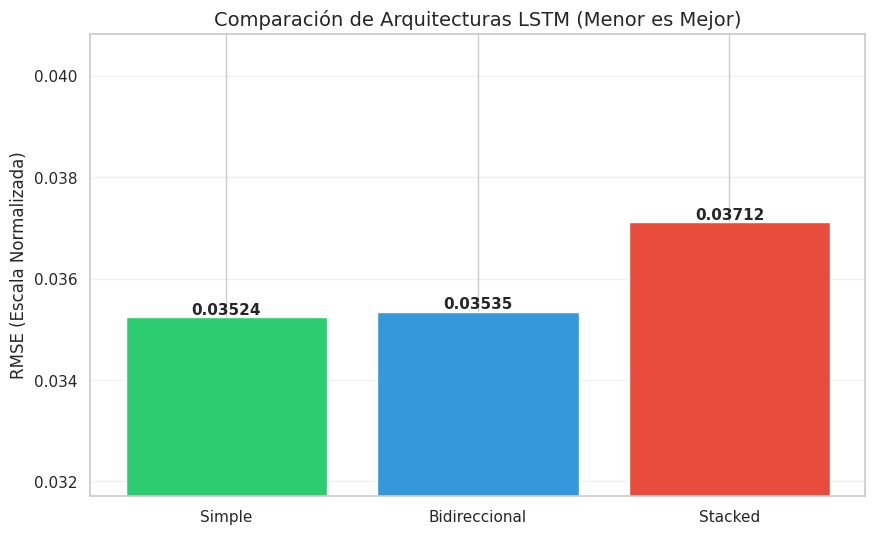

In [36]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout, BatchNormalization
from sklearn.metrics import mean_squared_error

# =============================================================================
# CONFIGURACIÓN DEL TORNEO
# =============================================================================
COMMON_CONFIG = {
    'lookback': 70,
    'horizon': 10,
    'dropout': 0.2,
    'epochs': 50,      # Reducimos un poco para que el torneo no tarde horas
    'batch_size': 64,
    'units': 128       # Neuronas base para estandarizar capacidad
}

COMMON_CONFIG = {
    'lookback': 50,
    'horizon': 15,
    'dropout': 0.4,
    'epochs': 50,
    'batch_size': 64,
    'units':128
}


# Asumimos que X_train, y_train, X_test, y_test ya existen en memoria del paso anterior
# y que 'scaler' también existe.

# =============================================================================
# 1. DEFINICIÓN DE LOS 3 COMPETIDORES
# =============================================================================

def build_simple_lstm(input_shape):
    model = Sequential(name="LSTM_Simple")
    model.add(Input(shape=input_shape))
    model.add(LSTM(COMMON_CONFIG['units'], return_sequences=False))
    model.add(Dropout(COMMON_CONFIG['dropout']))
    model.add(Dense(COMMON_CONFIG['horizon']))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_stacked_lstm(input_shape):
    model = Sequential(name="LSTM_Stacked")
    model.add(Input(shape=input_shape))
    # Capa 1
    model.add(LSTM(COMMON_CONFIG['units'], return_sequences=True))
    model.add(Dropout(COMMON_CONFIG['dropout']))
    # Capa 2
    model.add(LSTM(COMMON_CONFIG['units'] // 2, return_sequences=False))
    model.add(Dropout(COMMON_CONFIG['dropout']))
    
    model.add(Dense(COMMON_CONFIG['horizon']))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bidirectional_lstm(input_shape):
    model = Sequential(name="LSTM_Bidireccional")
    model.add(Input(shape=input_shape))
    # Bidireccional (Equivale a doblar neuronas en procesamiento)
    model.add(Bidirectional(LSTM(COMMON_CONFIG['units'], return_sequences=False)))
    model.add(Dropout(COMMON_CONFIG['dropout']))
    model.add(Dense(COMMON_CONFIG['horizon']))
    model.compile(optimizer='adam', loss='mse')
    return model

# =============================================================================
# 2. EJECUCIÓN DEL TORNEO
# =============================================================================

modelos = {
    "Simple": build_simple_lstm,
    "Stacked": build_stacked_lstm,
    "Bidireccional": build_bidirectional_lstm
}

resultados = []

print(f"🥊 INICIANDO TORNEO DE MODELOS ({COMMON_CONFIG['epochs']} épocas c/u)...")

for nombre, builder in modelos.items():
    print(f"\n⚡ Entrenando: {nombre}...")
    
    # Construir
    model = builder((X_train.shape[1], X_train.shape[2]))
    
    # Entrenar (Usamos MSE estándar para que la comparación sea justa en arquitectura puro)
    # Nota: No usamos la Loss personalizada aquí para aislar el efecto de la ARQUITECTURA.
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=COMMON_CONFIG['epochs'],
        batch_size=COMMON_CONFIG['batch_size'],
        verbose=0  # Silencioso para no ensuciar la pantalla
    )
    
    # Evaluar
    pred_scaled = model.predict(X_test, verbose=0)
    
    # Calcular RMSE Global (en escala normalizada para rapidez comparativa)
    rmse_test = np.sqrt(mean_squared_error(y_test.flatten(), pred_scaled.flatten()))
    
    # Guardar métricas
    resultados.append({
        "Modelo": nombre,
        "RMSE_Test_Norm": rmse_test,
        "Val_Loss_Final": history.history['val_loss'][-1],
        "Params": model.count_params()
    })
    
    print(f"   -> Terminado. RMSE Norm: {rmse_test:.5f}")

# =============================================================================
# 3. VISUALIZACIÓN DE RESULTADOS
# =============================================================================
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('RMSE_Test_Norm')

print("\n🏆 TABLA DE POSICIONES:")
print(df_resultados)

# Gráfico de Barras
plt.figure(figsize=(10, 6))
bars = plt.bar(df_resultados['Modelo'], df_resultados['RMSE_Test_Norm'], color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Comparación de Arquitecturas LSTM (Menor es Mejor)', fontsize=14)
plt.ylabel('RMSE (Escala Normalizada)')
plt.ylim(df_resultados['RMSE_Test_Norm'].min() * 0.9, df_resultados['RMSE_Test_Norm'].max() * 1.1)
plt.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), ha='center', va='bottom', fontweight='bold')

plt.show()

/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


🥊 INICIANDO TORNEO JUSTO (Todos usan Weighted Focal Loss)...
------------------------------------------------------------
🔄 Entrenando Modelo: Simple...
   ✅ Simple: Global=0.0932 | Eventos=0.1498
🔄 Entrenando Modelo: Stacked...
   ✅ Stacked: Global=0.0814 | Eventos=0.1817
🔄 Entrenando Modelo: Bidireccional...
   ✅ Bidireccional: Global=0.0852 | Eventos=0.1591

🏆 TABLA FINAL DE RESULTADOS (BAJO CONDICIONES DE TORMENTA):
               RMSE Global  RMSE Eventos (>0.6)
Modelo                                         
Simple            0.093220             0.149815
Stacked           0.081445             0.181695
Bidireccional     0.085161             0.159111


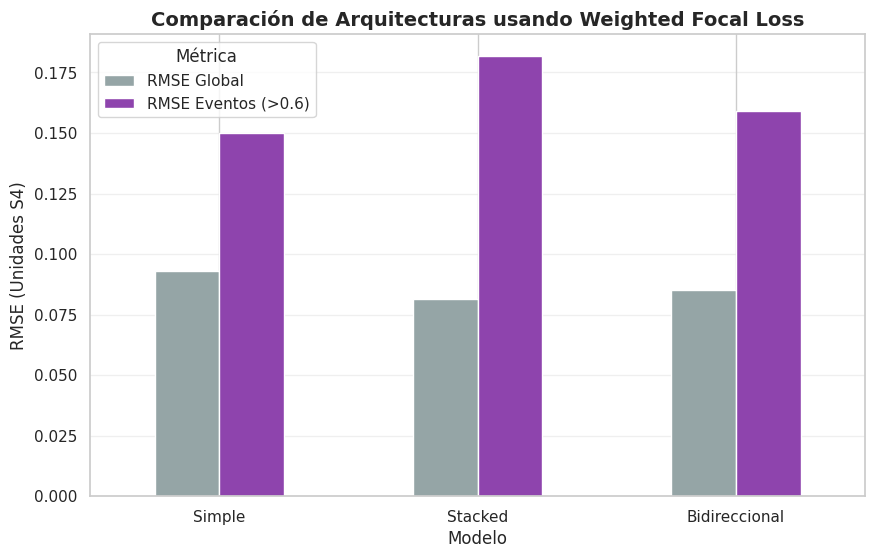

In [38]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from sklearn.metrics import mean_squared_error

# =============================================================================
# 0. PREPARACIÓN (DEFINIR LA LOSS FUNCTION Y EL UMBRAL)
# =============================================================================
# Recuperamos tu función de pérdida personalizada
def weighted_focal_mse_multistep(threshold, alpha, beta):
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

# Calculamos el umbral normalizado (igual que en el entrenamiento principal)
input_cols = [c for c in FEATURES_COLS if c != 'Fecha']
idx_target = input_cols.index('S4')
dummy = np.zeros((1, len(input_cols)))
dummy[0, idx_target] = 0.6 
umbral_norm = scaler.transform(dummy)[0, idx_target]

# Definimos la Loss Function configurada
loss_fn_torneo = weighted_focal_mse_multistep(threshold=umbral_norm, alpha=2.0, beta=50.0)

# =============================================================================
# 1. CONFIGURACIÓN DEL TORNEO
# =============================================================================
TOURNAMENT_CONFIG = {
    'lookback': 70,
    'horizon': 10,
    'units': 64,         
    'dropout': 0.2,
    'epochs': 40,        # Un poco más de épocas porque la Focal Loss es más difícil de optimizar
    'batch_size': 64,
    'input_shape': (X_train.shape[1], X_train.shape[2]) 
}


TOURNAMENT_CONFIG = {
    'lookback': 50,
    'horizon': 15,
    'units':128,
    'dropout': 0.4,
    'epochs': 50,
    'batch_size': 64,
    'input_shape': (X_train.shape[1], X_train.shape[2]) 
}

# =============================================================================
# 2. DEFINICIÓN DE LOS 3 GLADIADORES (AHORA CON CUSTOM LOSS)
# =============================================================================

def get_simple_lstm():
    model = Sequential(name="LSTM_Simple")
    model.add(Input(shape=TOURNAMENT_CONFIG['input_shape']))
    model.add(LSTM(TOURNAMENT_CONFIG['units'], return_sequences=False))
    model.add(Dropout(TOURNAMENT_CONFIG['dropout']))
    model.add(Dense(TOURNAMENT_CONFIG['horizon']))
    # AQUI ESTA EL CAMBIO: Usamos tu loss function
    model.compile(optimizer='adam', loss=loss_fn_torneo) 
    return model

def get_stacked_lstm():
    model = Sequential(name="LSTM_Stacked")
    model.add(Input(shape=TOURNAMENT_CONFIG['input_shape']))
    model.add(LSTM(TOURNAMENT_CONFIG['units'], return_sequences=True))
    model.add(Dropout(TOURNAMENT_CONFIG['dropout']))
    model.add(LSTM(TOURNAMENT_CONFIG['units'], return_sequences=False))
    model.add(Dropout(TOURNAMENT_CONFIG['dropout']))
    model.add(Dense(TOURNAMENT_CONFIG['horizon']))
    # AQUI ESTA EL CAMBIO: Usamos tu loss function
    model.compile(optimizer='adam', loss=loss_fn_torneo)
    return model

def get_bidirectional_lstm():
    model = Sequential(name="LSTM_Bidireccional")
    model.add(Input(shape=TOURNAMENT_CONFIG['input_shape']))
    model.add(Bidirectional(LSTM(TOURNAMENT_CONFIG['units'], return_sequences=False)))
    model.add(Dropout(TOURNAMENT_CONFIG['dropout']))
    model.add(Dense(TOURNAMENT_CONFIG['horizon']))
    # AQUI ESTA EL CAMBIO: Usamos tu loss function
    model.compile(optimizer='adam', loss=loss_fn_torneo)
    return model

# =============================================================================
# 3. HELPER: DESNORMALIZACIÓN (Igual que antes)
# =============================================================================
def desnormalizar_predicciones(y_pred_scaled, y_true_scaled, scaler, idx_target, n_features):
    pred_flat = y_pred_scaled.flatten()
    true_flat = y_true_scaled.flatten()
    dummy_pred = np.zeros((len(pred_flat), n_features))
    dummy_true = np.zeros((len(true_flat), n_features))
    dummy_pred[:, idx_target] = pred_flat
    dummy_true[:, idx_target] = true_flat
    inv_pred = scaler.inverse_transform(dummy_pred)[:, idx_target]
    inv_true = scaler.inverse_transform(dummy_true)[:, idx_target]
    return inv_true, inv_pred

# =============================================================================
# 4. EJECUCIÓN (CON LA MISMA VARA DE MEDIR)
# =============================================================================
modelos = {
    "Simple": get_simple_lstm,
    "Stacked": get_stacked_lstm,
    "Bidireccional": get_bidirectional_lstm
}

resultados = []

print(f"🥊 INICIANDO TORNEO JUSTO (Todos usan Weighted Focal Loss)...")
print("-" * 60)

for nombre, constructor in modelos.items():
    print(f"🔄 Entrenando Modelo: {nombre}...")
    
    # 1. Instanciar y Entrenar
    model = constructor()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=TOURNAMENT_CONFIG['epochs'],
        batch_size=TOURNAMENT_CONFIG['batch_size'],
        verbose=0 
    )
    
    # 2. Predecir
    pred_scaled = model.predict(X_test, verbose=0)
    
    # 3. Desnormalizar
    y_real, y_pred = desnormalizar_predicciones(
        pred_scaled, y_test, scaler, idx_target, len(input_cols)
    )
    
    # 4. Calcular Métricas
    rmse_global = np.sqrt(mean_squared_error(y_real, y_pred))
    
    mask_eventos = y_real >= 0.6
    if np.sum(mask_eventos) > 0:
        rmse_eventos = np.sqrt(mean_squared_error(y_real[mask_eventos], y_pred[mask_eventos]))
    else:
        rmse_eventos = 0.0
        
    resultados.append({
        'Modelo': nombre,
        'RMSE Global': rmse_global,
        'RMSE Eventos (>0.6)': rmse_eventos
    })
    
    print(f"   ✅ {nombre}: Global={rmse_global:.4f} | Eventos={rmse_eventos:.4f}")

# =============================================================================
# 5. VISUALIZACIÓN
# =============================================================================
df_res = pd.DataFrame(resultados).set_index('Modelo')

print("\n🏆 TABLA FINAL DE RESULTADOS (BAJO CONDICIONES DE TORMENTA):")
print(df_res)

ax = df_res[['RMSE Global', 'RMSE Eventos (>0.6)']].plot(kind='bar', figsize=(10, 6), color=['#95a5a6', '#8e44ad'])
plt.title('Comparación de Arquitecturas usando Weighted Focal Loss', fontsize=14, fontweight='bold')
plt.ylabel('RMSE (Unidades S4)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Métrica')
plt.show()

# **MODELO GANADOR STACKER**

🚀 INICIANDO ENTRENAMIENTO DEL MODELO DEFINITIVO...
   Features de Entrada (9): ['S4', 'TEC', 'ROTI', 'Kp_Index', 'Dst_Index', 'AE_Index', 'f10.7_Index', 'Hora_Sin', 'Hora_Cos']
   Target: S4

📦 Creando ventanas temporales (esto puede tardar unos segundos)...
   Dimensiones Train: X=(176787, 50, 9), y=(176787, 15)
   Dimensiones Val:   X=(40019, 50, 9)
   Dimensiones Test:  X=(40250, 50, 9)
   Umbral S4=0.6 (Físico) --> 0.4079 (Normalizado)


/home/soporte/anaconda3/envs/s4_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Model: "LSTM_Stacked_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 128)        │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,087 (512.06 KB)

 Trainable params: 130,703 (510.56 KB)

 Non-trainable params: 384 (1.50 KB)


🔥 ENTRENANDO... (Ve por un café ☕)
Epoch 1/100
2755/2763 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5770 - mae: 0.3747 
Epoch 1: val_loss improved from inf to 0.00179, saving model to modelo_final_JICAMARCA.keras
2763/2763 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.5757 - mae: 0.3743 - val_loss: 0.0018 - val_mae: 0.0771 - learning_rate: 0.0010
Epoch 2/100
2758/2763 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0131 - mae: 0.1566 
Epoch 2: val_loss did not improve from 0.00179
2763/2763 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 0.0131 - mae: 0.1566 - val_loss: 0.0026 - val_mae: 0.0460 - learning_rate: 0.0010
Epoch 3/100
2754/2763 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056 - mae: 0.1095 
Epoch 3: val_loss did not improve from 0.00179
2763/2763 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 0.0056 - mae: 0.1094 - val_loss: 0.0181 - val_mae: 0.2379 - learning_rate: 0.0010
Epoch 4/100
2751/2763 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - mae: 0.0858 
Epoch 4: val_loss did not improve f

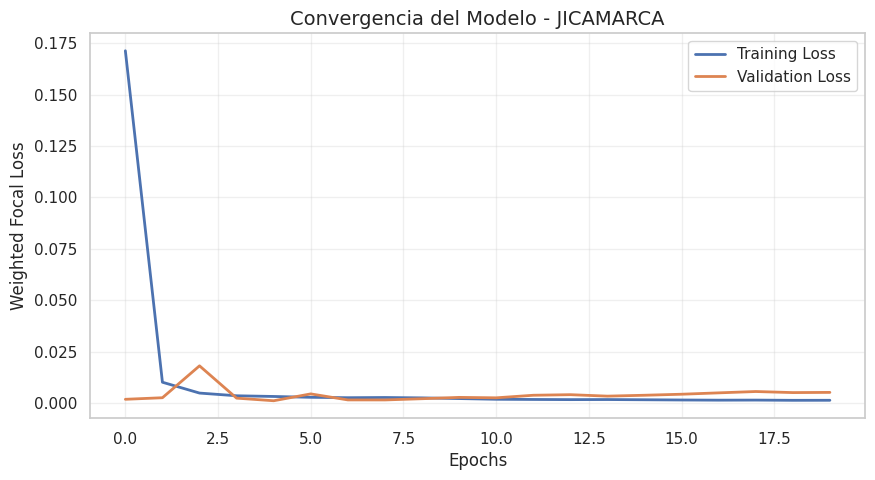

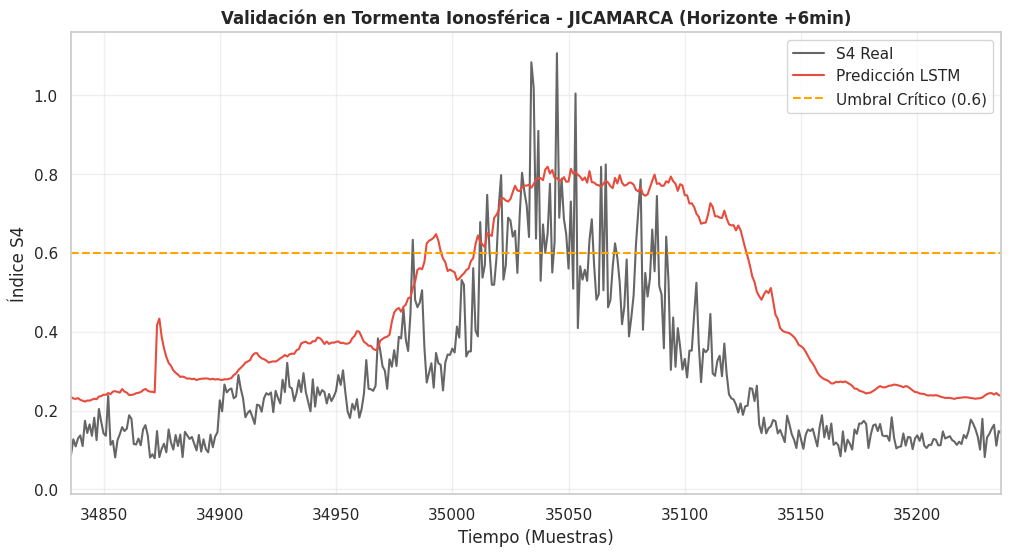

In [39]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================================
# 1. LA RECETA MAESTRA (Configuración Ganadora)
# =============================================================================
BEST_CONFIG = {
    'lookback': 70,           # 70 minutos de historia
    'horizon': 10,            # Predecir 10 minutos al futuro
    'lstm_units': (128, 64),  # Arquitectura profunda (128 -> 64)
    'dropout': 0.2,           # Regularización
    'alpha': 2.0,             # Enfoque cuadrático en errores
    'beta': 50.0,             # Peso x50 para eventos > 0.6
    'batch_size': 64,         # Tamaño de lote
    'epochs': 100             # Límite (Early Stopping cortará antes)
}

BEST_CONFIG = {
    'lookback': 50,
    'horizon': 15,
    'lstm_units': (128, 64),  # Arquitectura profunda (128 -> 64)
    'dropout': 0.4,
    'alpha': 1.5,
    'beta': 80.0,
    'batch_size': 64,
    'epochs': 100
}


# Nombre de la columna objetivo
TARGET_COL = 'S4' 

# =============================================================================
# 2. GENERADOR DE VENTANAS (TENSORIZACIÓN)
# =============================================================================
def crear_dataset_lstm_final(df_scaled, cols_input, col_target, lookback, horizon):
    """
    Convierte el DataFrame escalado en tensores X (input) e y (output).
    Ignora columnas no numéricas como 'Fecha'.
    """
    # Filtramos solo las columnas numéricas de entrada
    # (Asegúrate que cols_input NO tenga 'Fecha')
    data_values = df_scaled[cols_input].values
    target_values = df_scaled[col_target].values
    
    # Usamos el índice para controlar los saltos de tiempo
    timestamps = df_scaled.index.to_series().values
    
    X, y = [], []
    
    # Recorremos el dataset
    for i in range(lookback, len(df_scaled) - horizon):
        t_inicio = timestamps[i - lookback]
        t_actual = timestamps[i]
        t_fin    = timestamps[i + horizon - 1]
        
        # 1. Validar continuidad de entrada (Lookback)
        diff_entrada = (t_actual - t_inicio) / np.timedelta64(1, 'm')
        if diff_entrada != lookback: continue
            
        # 2. Validar continuidad de salida (Horizonte)
        diff_salida = (t_fin - t_actual) / np.timedelta64(1, 'm')
        if diff_salida != (horizon - 1): continue
            
        # 3. Validar huecos internos (Gap Check)
        tiempos_futuros = timestamps[i : i + horizon]
        diffs = np.diff(tiempos_futuros) / np.timedelta64(1, 'm')
        if not np.all(diffs == 1): continue
            
        # Si todo es continuo, guardamos la ventana
        X.append(data_values[i - lookback : i])
        y.append(target_values[i : i + horizon])
        
    return np.array(X), np.array(y)

# =============================================================================
# 3. FUNCIÓN DE PÉRDIDA PERSONALIZADA (EL CEREBRO DEL MODELO)
# =============================================================================
def weighted_focal_mse_multistep(threshold, alpha, beta):
    """
    Loss function diseñada para forzar el aprendizaje de tormentas ionosféricas.
    """
    def loss(y_true, y_pred):
        error = y_pred - y_true
        squared_error = tf.square(error)
        
        # 1. Peso por Intensidad (Si es tormenta, importa 50 veces más)
        weights = tf.where(y_true >= threshold, beta, 1.0)
        
        # 2. Enfoque Focal (Si el error es grande, castigarlo exponencialmente)
        focal_weight = tf.pow(tf.abs(error) + 1e-7, alpha)
        
        # 3. Penalización por Subestimación (Si predice bajo cuando es alto)
        underestimation_mask = tf.logical_and(y_true >= threshold, y_pred < y_true * 0.8)
        under_penalty = tf.where(underestimation_mask, 2.0, 1.0)
        
        total_loss = squared_error * weights * focal_weight * under_penalty
        return tf.reduce_mean(total_loss)
    return loss

# =============================================================================
# 4. ARQUITECTURA DEL MODELO (EL CUERPO - VERSIÓN STACKED)
# =============================================================================
def construir_modelo_ganador(input_shape, config, umbral_norm):
    tf.keras.backend.clear_session()
    
    # Actualizamos el nombre para identificarlo en los logs
    model = Sequential(name="LSTM_Stacked_Final")
    model.add(Input(shape=input_shape))
    
    # Capa 1: Primera capa profunda (Se elimina la envoltura Bidirectional)
    model.add(LSTM(config['lstm_units'][0], return_sequences=True))
    model.add(BatchNormalization())
    model.add(Dropout(config['dropout']))
    
    # Capa 2: Segunda capa profunda (Se elimina la envoltura Bidirectional)
    model.add(LSTM(config['lstm_units'][1], return_sequences=False))
    model.add(BatchNormalization())
    model.add(Dropout(config['dropout']))
    
    # Decoder (Cabeza de predicción) - Queda exactamente igual
    model.add(Dense(config['lstm_units'][0], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(config['horizon'], activation='linear')) # Salida vector (10 pasos)
    
    # Compilación - Queda exactamente igual
    loss_fn = weighted_focal_mse_multistep(
        threshold=umbral_norm, 
        alpha=config['alpha'], 
        beta=config['beta']
    )
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss=loss_fn, 
                  metrics=['mae'])
    return model

# =============================================================================
# 5. EJECUCIÓN DEL ENTRENAMIENTO
# =============================================================================
if __name__ == "__main__":
    
    print("🚀 INICIANDO ENTRENAMIENTO DEL MODELO DEFINITIVO...")

    # 1. Limpieza de columnas para tensores (Quitamos 'Fecha' si existe)
    # Definimos features numéricas basadas en FEATURES_COLS del paso anterior
    input_cols = [c for c in FEATURES_COLS if c != 'Fecha']
    
    print(f"   Features de Entrada ({len(input_cols)}): {input_cols}")
    print(f"   Target: {TARGET_COL}")

    # 2. Generación de Tensores
    print("\n📦 Creando ventanas temporales (esto puede tardar unos segundos)...")
    X_train, y_train = crear_dataset_lstm_final(train_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    X_val, y_val     = crear_dataset_lstm_final(val_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    X_test, y_test   = crear_dataset_lstm_final(test_scaled, input_cols, TARGET_COL, BEST_CONFIG['lookback'], BEST_CONFIG['horizon'])
    
    print(f"   Dimensiones Train: X={X_train.shape}, y={y_train.shape}")
    print(f"   Dimensiones Val:   X={X_val.shape}")
    print(f"   Dimensiones Test:  X={X_test.shape}")

    # 3. Calcular Umbral S4=0.6 Normalizado
    # Necesario para que la Loss Function sepa qué es una tormenta en escala 0-1
    idx_target = input_cols.index(TARGET_COL)
    
    dummy = np.zeros((1, len(input_cols)))
    dummy[0, idx_target] = 0.6 # Valor físico real
    umbral_norm = scaler.transform(dummy)[0, idx_target]
    
    print(f"   Umbral S4=0.6 (Físico) --> {umbral_norm:.4f} (Normalizado)")

    # 4. Construir Modelo
    model = construir_modelo_ganador(
        input_shape=(BEST_CONFIG['lookback'], len(input_cols)),
        config=BEST_CONFIG,
        umbral_norm=umbral_norm
    )
    model.summary()

    # 5. Callbacks (Guardado automático del mejor modelo)
    checkpoint_path = f"modelo_final_{ESTACION[N_ESTACION]}.keras"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
    ]

    # 6. Entrenar
    print("\n🔥 ENTRENANDO... (Ve por un café ☕)")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=BEST_CONFIG['epochs'],
        batch_size=BEST_CONFIG['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    # 7. Guardar Scaler para uso futuro
    joblib.dump(scaler, f"scaler_final_{ESTACION[N_ESTACION]}.pkl")
    print(f"\n✅ Entrenamiento finalizado. Modelo guardado en: {checkpoint_path}")

    # =============================================================================
    # 6. EVALUACIÓN Y GRÁFICOS DE TESIS
    # =============================================================================
    print("\n📊 Generando Métricas Finales...")

    # A. Predicción en Test
    y_pred_scaled = model.predict(X_test, verbose=0)

    # B. Desnormalización Inteligente (Solo Target)
    def inverse_transform_target(y_scaled_tensor, scaler, feat_idx, n_features):
        """Desnormaliza solo la columna target de una matriz de predicciones."""
        y_inv = np.zeros_like(y_scaled_tensor)
        dummy = np.zeros((len(y_scaled_tensor), n_features))
        
        for step in range(y_scaled_tensor.shape[1]): # Para cada paso del horizonte (0 a 9)
            dummy[:, feat_idx] = y_scaled_tensor[:, step]
            inv_vals = scaler.inverse_transform(dummy)[:, feat_idx]
            y_inv[:, step] = inv_vals
        return y_inv

    y_test_real = inverse_transform_target(y_test, scaler, idx_target, len(input_cols))
    y_pred_real = inverse_transform_target(y_pred_scaled, scaler, idx_target, len(input_cols))

    # C. Cálculo de Métricas
    # Aplanamos para comparar todo contra todo
    rmse_global = np.sqrt(mean_squared_error(y_test_real.flatten(), y_pred_real.flatten()))
    
    # RMSE Específico para Eventos > 0.6
    mask_eventos = y_test_real >= 0.6
    if np.sum(mask_eventos) > 0:
        rmse_eventos = np.sqrt(mean_squared_error(y_test_real[mask_eventos], y_pred_real[mask_eventos]))
    else:
        rmse_eventos = 0.0

    print("="*40)
    print(f"🏆 RESULTADOS FINALES ({ESTACION[N_ESTACION]})")
    print(f"   RMSE Global (Todo el test):   {rmse_global:.4f}")
    print(f"   RMSE EVENTOS (S4 > 0.6):      {rmse_eventos:.4f}  <-- DATO CLAVE TESIS")
    print("="*40)

    # D. Gráfico 1: Curva de Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title(f'Convergencia del Modelo - {ESTACION[N_ESTACION]}', fontsize=14)
    plt.ylabel('Weighted Focal Loss')
    plt.xlabel('Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # E. Gráfico 2: Predicción vs Real (Zoom en Evento)
    # Buscamos el índice con el mayor S4 en el test para graficar eso
    idx_max_s4 = np.argmax(np.max(y_test_real, axis=1))
    
    plt.figure(figsize=(12, 6))
    # Graficamos el paso 5 (mitad del horizonte)
    paso_horizonte = 5 
    
    plt.plot(y_test_real[:, paso_horizonte], label='S4 Real', color='black', alpha=0.6)
    plt.plot(y_pred_real[:, paso_horizonte], label='Predicción LSTM', color='#e74c3c', linewidth=1.5)
    
    plt.axhline(0.6, color='orange', linestyle='--', label='Umbral Crítico (0.6)')
    
    # Hacemos zoom alrededor del evento máximo
    zoom_window = 200 # Muestras a izq y der
    plt.xlim(max(0, idx_max_s4 - zoom_window), min(len(y_test_real), idx_max_s4 + zoom_window))
    
    plt.title(f'Validación en Tormenta Ionosférica - {ESTACION[N_ESTACION]} (Horizonte +{paso_horizonte+1}min)', fontweight='bold')
    plt.xlabel('Tiempo (Muestras)')
    plt.ylabel('Índice S4')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


⚡ BUSCANDO TORMENTAS EN EL SET DE TEST (Top 5 días más críticos)...
✅ Se encontraron 16 días distintos con eventos de tormenta.


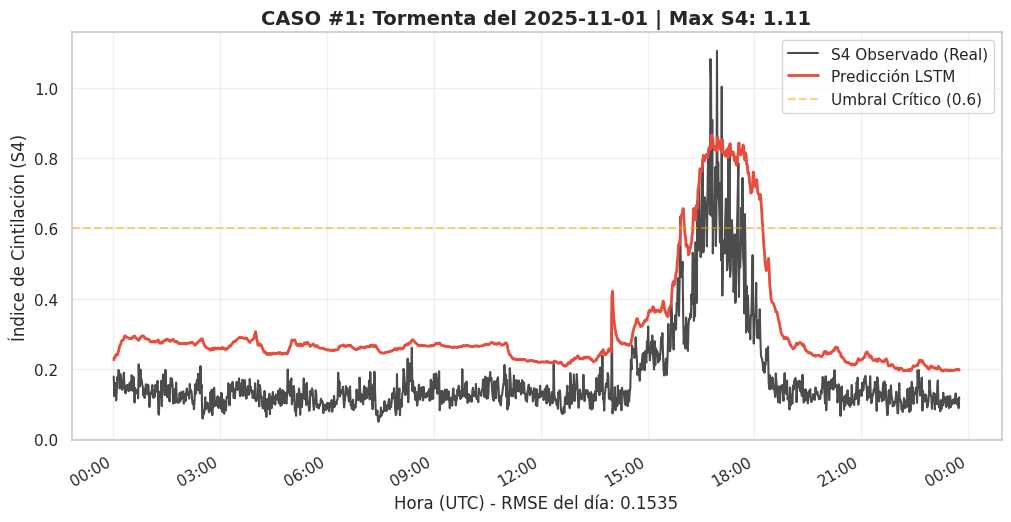

   -> Gráfico generado para el día 2025-11-01 (Max S4: 1.11)


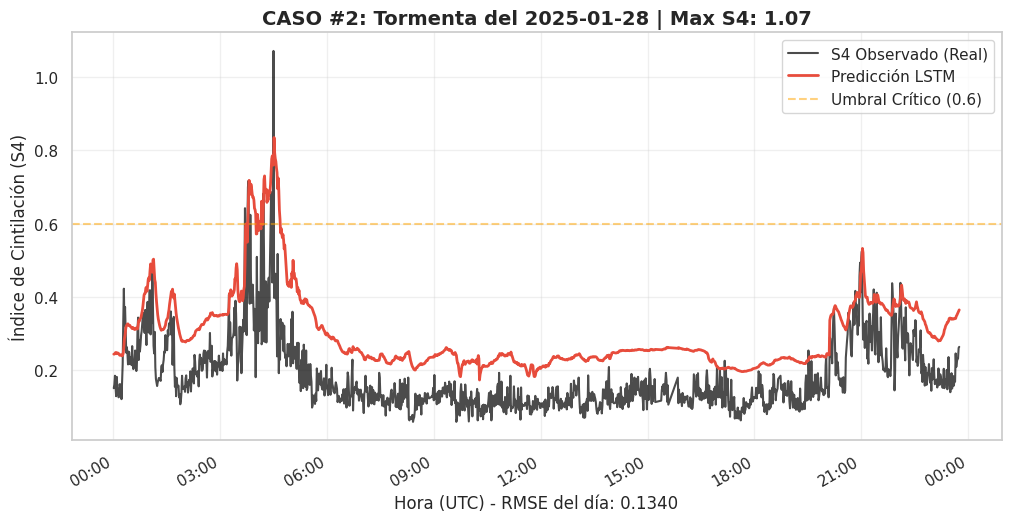

   -> Gráfico generado para el día 2025-01-28 (Max S4: 1.07)


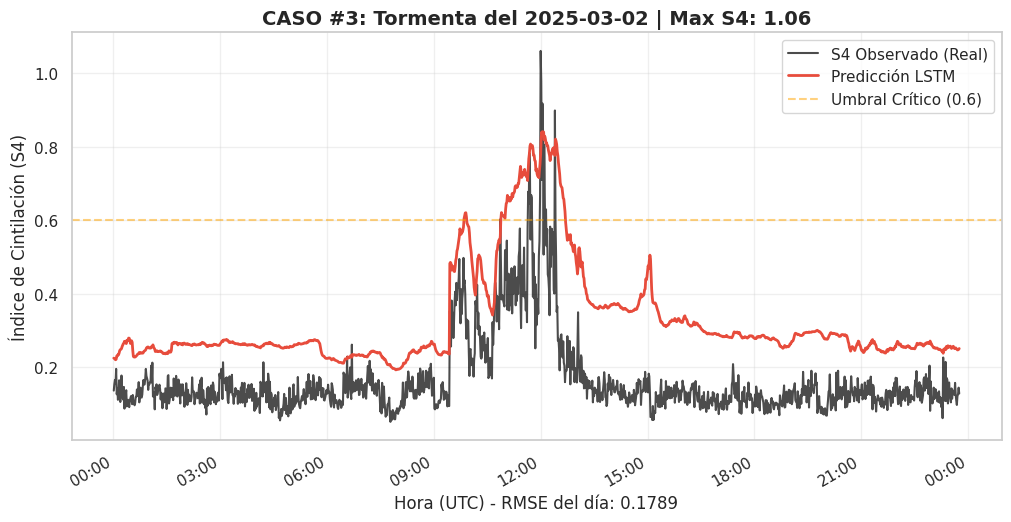

   -> Gráfico generado para el día 2025-03-02 (Max S4: 1.06)


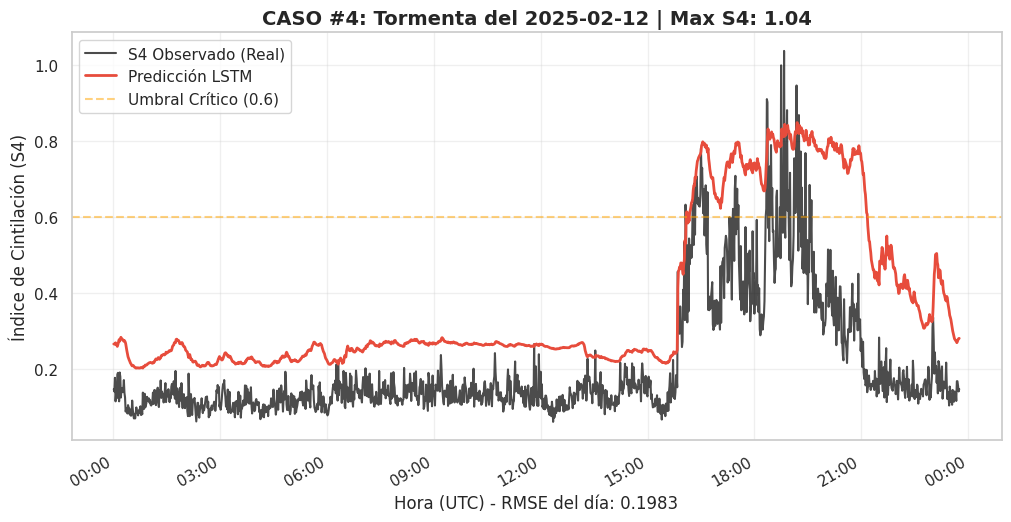

   -> Gráfico generado para el día 2025-02-12 (Max S4: 1.04)


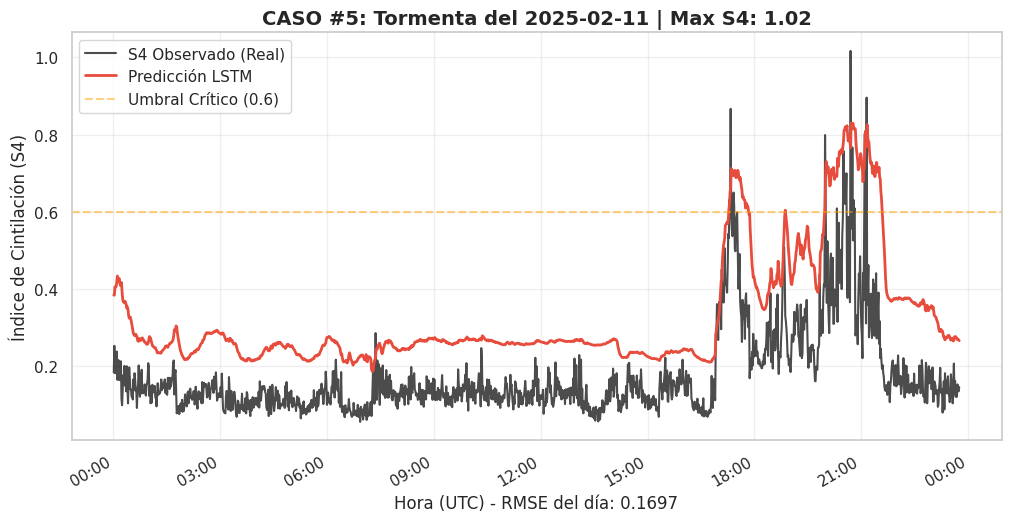

   -> Gráfico generado para el día 2025-02-11 (Max S4: 1.02)


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def visualizar_top_tormentas(model, X_test, y_test, scaler, test_indices, config, feature_cols, target_col, top_n=5):
    """
    Busca días con tormentas en el set de Test y grafica la comparación Real vs Predicho
    con fecha y hora exacta.
    """
    print(f"\n⚡ BUSCANDO TORMENTAS EN EL SET DE TEST (Top {top_n} días más críticos)...")
    
    # 1. Realizar Predicciones
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # 2. Desnormalizar (Solo Target)
    # Necesitamos reconstruir la escala real para saber si S4 > 0.6
    idx_target = feature_cols.index(target_col)
    n_features = len(feature_cols)
    
    def inverse_transform_column(y_tensor, scaler, feat_idx, n_feats):
        y_inv = np.zeros_like(y_tensor)
        dummy = np.zeros((len(y_tensor), n_feats))
        # Desnormalizamos paso a paso (usamos el paso 0 del horizonte como referencia)
        for i in range(len(y_tensor)):
            dummy[i, feat_idx] = y_tensor[i, 0] # Miramos el primer paso de predicción (t+1)
        
        # Transformación inversa en bloque (más rápido)
        inv_matrix = scaler.inverse_transform(dummy)
        return inv_matrix[:, feat_idx]

    # Obtenemos vectores 1D de la realidad y predicción (primer paso del horizonte)
    y_test_real_1d = inverse_transform_column(y_test, scaler, idx_target, n_features)
    y_pred_real_1d = inverse_transform_column(y_pred_scaled, scaler, idx_target, n_features)
    
    # 3. Alinear con Fechas
    # El índice i en X_test corresponde a: test_indices[i + lookback]
    # Ajustamos los índices para que coincidan con el vector de predicciones
    start_idx = config['lookback']
    end_idx = len(test_indices) - config['horizon'] 
    
    # Nota: El generador de ventanas a veces recorta el final si no es divisible exacto o por los gaps.
    # Aseguramos la longitud:
    valid_dates = test_indices[start_idx : start_idx + len(y_test_real_1d)]
    
    # Creamos un DataFrame temporal para facilitar el filtrado por fechas
    df_eval = pd.DataFrame({
        'FechaHora': valid_dates,
        'S4_Real': y_test_real_1d,
        'S4_Pred': y_pred_real_1d
    })
    df_eval['Dia'] = df_eval['FechaHora'].dt.date

    # 4. Encontrar Días Únicos con Tormenta (> 0.6)
    dias_tormenta = df_eval[df_eval['S4_Real'] > 0.6]['Dia'].unique()
    
    if len(dias_tormenta) == 0:
        print("⚠️ No se encontraron eventos S4 > 0.6 en el set de Test.")
        return

    print(f"✅ Se encontraron {len(dias_tormenta)} días distintos con eventos de tormenta.")

    # 5. Seleccionar los 'top_n' días con el pico más alto
    rank_dias = []
    for dia in dias_tormenta:
        max_s4_dia = df_eval[df_eval['Dia'] == dia]['S4_Real'].max()
        rank_dias.append((dia, max_s4_dia))
    
    # Ordenar por intensidad de S4 (Mayor a menor)
    rank_dias.sort(key=lambda x: x[1], reverse=True)
    top_dias = rank_dias[:top_n]

    # 6. Graficar cada día
    for i, (dia, max_s4) in enumerate(top_dias):
        # Filtramos datos de ESE día
        mask_dia = df_eval['Dia'] == dia
        df_dia = df_eval[mask_dia]
        
        # Calculamos error local
        rmse_local = np.sqrt(np.mean((df_dia['S4_Real'] - df_dia['S4_Pred'])**2))
        
        plt.figure(figsize=(12, 6))
        
        plt.plot(df_dia['FechaHora'], df_dia['S4_Real'], label='S4 Observado (Real)', color='black', alpha=0.7)
        plt.plot(df_dia['FechaHora'], df_dia['S4_Pred'], label='Predicción LSTM', color='#e74c3c', linewidth=2)
        
        # Línea de umbral
        plt.axhline(0.6, color='orange', linestyle='--', alpha=0.5, label='Umbral Crítico (0.6)')
        
        # Formato de fechas en eje X
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.gcf().autofmt_xdate()
        
        plt.title(f"CASO #{i+1}: Tormenta del {dia} | Max S4: {max_s4:.2f}", fontsize=14, fontweight='bold')
        plt.xlabel(f"Hora (UTC) - RMSE del día: {rmse_local:.4f}")
        plt.ylabel("Índice de Cintilación (S4)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        print(f"   -> Gráfico generado para el día {dia} (Max S4: {max_s4:.2f})")

# =============================================================================
# EJECUCIÓN (Asegúrate de tener las variables del entrenamiento anterior)
# =============================================================================

# Necesitamos el índice original de TEST para recuperar las fechas.
# Como usamos 'test_scaled' en el paso anterior y ese DF conservaba el índice:
indices_test = test_scaled.index 

# Lista de columnas usadas en el entrenamiento (sin 'Fecha')
# Debe coincidir con 'input_cols' del script anterior
cols_input_modelo = [c for c in FEATURES_COLS if c != 'Fecha'] 

visualizar_top_tormentas(
    model=model,
    X_test=X_test, 
    y_test=y_test, 
    scaler=scaler, 
    test_indices=indices_test, 
    config=BEST_CONFIG, 
    feature_cols=cols_input_modelo, 
    target_col='S4',
    top_n=5  # <--- CAMBIA ESTO SI QUIERES VER MÁS O MENOS DÍAS
)


📊 EVALUACIÓN DE DETECCIÓN DE EVENTOS (Umbral S4 > 0.6)
Total de Puntos Evaluados: 257200
Total de Puntos de Tormenta Reales: 740
------------------------------
✅ ACIERTOS (Verdaderos Positivos):  532  (Detectados correctamente)
❌ FUGAS (Falsos Negativos):        208  (Tormentas que el modelo no vio)
⚠️ FALSAS ALARMAS (Falsos Positivos): 2985  (Dijo tormenta, pero era calma)
------------------------------
📈 PORCENTAJE DE ACIERTO (Recall):    71.89%  <-- DATO CLAVE
🎯 CONFIABILIDAD (Precision):         15.13%
⚖️ F1-SCORE (Balance):                0.2499


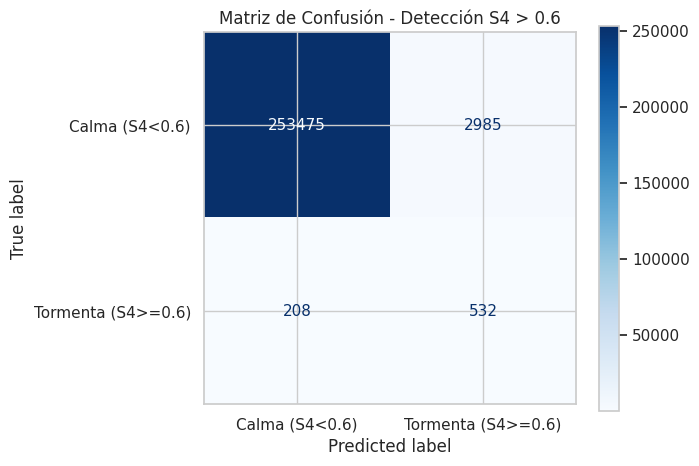

In [97]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def evaluar_capacidad_deteccion(y_real, y_pred, umbral=0.6):
    """
    Convierte las predicciones continuas en binarias (Evento vs No Evento)
    y calcula métricas de clasificación.
    """
    print(f"\n📊 EVALUACIÓN DE DETECCIÓN DE EVENTOS (Umbral S4 > {umbral})")
    print("="*60)

    # 1. Aplanar los arrays (comparamos punto por punto)
    # Convertimos matrices (N, 10) a vectores largos (N*10, )
    y_real_flat = y_real.flatten()
    y_pred_flat = y_pred.flatten()

    # 2. Binarizar (Convertir a 0 o 1)
    # 1 = Evento (Tormenta), 0 = Calma
    real_bin = (y_real_flat >= umbral).astype(int)
    pred_bin = (y_pred_flat >= umbral).astype(int)

    # 3. Calcular Matriz de Confusión
    tn, fp, fn, tp = confusion_matrix(real_bin, pred_bin).ravel()

    # 4. Cálculo manual de métricas clave para la Tesis
    total_muestras = len(real_bin)
    total_eventos_reales = tp + fn
    total_alertas_modelo = tp + fp
    
    # Sensibilidad (Recall): % de tormentas reales que atrapamos
    # EVITA DIVISIÓN POR CERO
    recall = tp / total_eventos_reales if total_eventos_reales > 0 else 0
    
    # Precisión: De las alertas que dio el modelo, ¿cuántas eran verdad?
    precision = tp / total_alertas_modelo if total_alertas_modelo > 0 else 0
    
    # F1-Score: Balance entre precisión y recall
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # 5. Reporte de Texto
    print(f"Total de Puntos Evaluados: {total_muestras}")
    print(f"Total de Puntos de Tormenta Reales: {total_eventos_reales}")
    print("-" * 30)
    print(f"✅ ACIERTOS (Verdaderos Positivos):  {tp}  (Detectados correctamente)")
    print(f"❌ FUGAS (Falsos Negativos):        {fn}  (Tormentas que el modelo no vio)")
    print(f"⚠️ FALSAS ALARMAS (Falsos Positivos): {fp}  (Dijo tormenta, pero era calma)")
    print("-" * 30)
    print(f"📈 PORCENTAJE DE ACIERTO (Recall):    {recall*100:.2f}%  <-- DATO CLAVE")
    print(f"🎯 CONFIABILIDAD (Precision):         {precision*100:.2f}%")
    print(f"⚖️ F1-SCORE (Balance):                {f1:.4f}")
    
    # 6. Visualización de la Matriz
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Etiquetas personalizadas
    labels = ['Calma (S4<0.6)', 'Tormenta (S4>=0.6)']
    
    cm = confusion_matrix(real_bin, pred_bin)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    
    # Dibujar con colores mapa de calor
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title(f'Matriz de Confusión - Detección S4 > {umbral}')
    plt.show()

# EJECUTAR LA FUNCIÓN
evaluar_capacidad_deteccion(y_test_real, y_pred_real, umbral=0.6)